In [ ]:
from google.colab import files
files.upload()

Saving houses.csv to houses.csv
Saving __notebook__.ipynb to __notebook__.ipynb


{'houses.csv': b'description,Bedroom,Bathroom,Property Size,Nearby School,Nearby Mall,Ad List,Category,Facilities,Building Name,Developer,Tenure Type,Address,Completion Year,# of Floors,Total Units,Property Type,Parking Lot,Floor Range,Land Title,Firm Type,Firm Number,REN Number,Bus Stop,Mall,Park,School,Hospital,price,Highway,Nearby Railway Station,Railway Station\n"Iconic Building @ KL SETAPAK\nNew launching & Latest condo !!!!! \xf0\x9f\x94\xa5\nHouse with luxury hotel concept \xf0\x9f\x98\x8d\xf0\x9f\x91\x91\n\xf0\x9f\x92\x8e Freehold\n\xf0\x9f\x94\x91 Dual key\n\xf0\x9f\x9b\x8c 2 / 3 / 4 rooms\n\xf0\x9f\x92\xb0Affordable and Low entry price\n\xf0\x9f\x92\xbc 100% full furnish, move in with a luggage\nWhatsapp / Call \nShow contact number\n ( Eugine ) for more details & showroom viewing \xf0\x9f\x94\xa5\nWhatsapp / Call \nShow contact number\n ( Eugine ) for more details & showroom viewing \xf0\x9f\x94\xa5\nWhatsapp / Call \nShow contact number\n ( Eugine ) for more details & showr

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
df = pd.read_csv("houses.csv")
df.head()

,description,Bedroom,Bathroom,Property Size,Nearby School,Nearby Mall,Ad List,Category,Facilities,Building Name,...,REN Number,Bus Stop,Mall,Park,School,Hospital,price,Highway,Nearby Railway Station,Railway Station
0,Iconic Building @ KL SETAPAK\nNew launching & ...,4,2,1000 sq.ft.,Sekolah Menengah Pendidikan Khas Cacat Penglih...,Setapak Central,98187451,"Apartment / Condominium, For sale",-,Kenwingston Platz,...,-,Bus Stop Starparc Point\nBus Stop Setapak Cent...,Setapak Central,"Park at Taman Tasik Danau Kota, Setapak, Kuala...",Sekolah Menengah Pendidikan Khas Cacat Penglih...,Columbia Asia Hospital,RM 340 000,NaN,NaN,NaN
1,"FOR SALE @ RM250,000\nIntroduction:\n~ Pangsap...",3,2,980 sq.ft.,NaN,NaN,101683090,"Apartment / Condominium, For sale","Parking, Security, Swimming Pool, Playground, ...",Kenanga (Park View Court),...,REN 15862,NaN,NaN,NaN,NaN,NaN,RM 250 000,NaN,NaN,NaN
2,"[Below Market] Sri Lavender Apartment,Tmn Sepa...",3,2,1000 sq.ft.,NaN,NaN,103792905,"Apartment / Condominium, For sale","Playground, Minimart, Jogging Track, Barbeque ...",Sri Lavender Apartment,...,-,NaN,NaN,NaN,NaN,NaN,RM 230 000,SILK Sg Ramal (T) Toll Plaza,NaN,NaN
3,Flat Pandan Indah\nJalan Pandan Indah 3/3\nNon...,3,1,592 sq.ft.,NaN,NaN,103806240,"Apartment / Condominium, For sale","Parking, Playground, Minimart, Jogging Track",Flat Pandan Indah,...,REN 16279,NaN,NaN,NaN,NaN,NaN,RM 158 000,NaN,NaN,NaN
4,"* Open-concept Soho with balcony, unblock view...",1,1,467 sq.ft.,Sekolah Jenis Kebangsaan (T) Ladang Midlands,i-Soho i-City,103806234,"Apartment / Condominium, For sale","Minimart, Gymnasium, Parking, Security",i-Soho @ i-City,...,-,Bus Stop at Persiaran Permai 1\nBus Stop at Pe...,i-Soho i-City\nGulati\nCentral i-City Shopping...,"Park 2 at Section 7, Shah Alam\nPark 1 at Sect...",Sekolah Jenis Kebangsaan (T) Ladang Midlands\n...,Osel Clinic (Shah Alam)\nHospital Shah Alam,RM 305 000,NaN,NaN,NaN


In [ ]:
df.info()
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   description             4000 non-null   object
 1   Bedroom                 4000 non-null   object
 2   Bathroom                4000 non-null   object
 3   Property Size           4000 non-null   object
 4   Nearby School           687 non-null    object
 5   Nearby Mall             365 non-null    object
 6   Ad List                 4000 non-null   int64 
 7   Category                4000 non-null   object
 8   Facilities              4000 non-null   object
 9   Building Name           4000 non-null   object
 10  Developer               4000 non-null   object
 11  Tenure Type             4000 non-null   object
 12  Address                 4000 non-null   object
 13  Completion Year         4000 non-null   object
 14  # of Floors             4000 non-null   object
 15  Tota

In [ ]:
df.describe(include='all')

,description,Bedroom,Bathroom,Property Size,Nearby School,Nearby Mall,Ad List,Category,Facilities,Building Name,...,REN Number,Bus Stop,Mall,Park,School,Hospital,price,Highway,Nearby Railway Station,Railway Station
count,4000,4000,4000,4000,687,365,4.000000e+03,4000,4000,4000,...,3797,708,475,807,948,343,4000,141,363,485
unique,3689,9,9,849,253,92,NaN,1,2202,1938,...,963,336,132,357,429,79,562,31,93,142
top,"Nearby Malaysia Largest Shopping Mall, Ready t...",3,2,700 sq.ft.,Vikas International School,Setapak Central,NaN,"Apartment / Condominium, For sale",-,-,...,-,Bus Stop KL 1284 Wisma Buddist\nBus Stop KL 11...,Mid Valley Megamall,"Park at Taman Halimahton, Seputeh, Kuala Lumpu...",Vikas International School,Columbia Asia Hospital,RM 350 000,Loke Yew Toll Plaza,KTM Station Batu Caves (Komuter Seremban Line),KTM Station Batu Caves (Komuter Seremban Line)
freq,8,2926,3125,201,19,19,NaN,4000,641,87,...,833,26,26,26,26,26,81,17,23,35
mean,NaN,NaN,NaN,NaN,NaN,NaN,1.024432e+08,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,3.025169e+06,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,3.096492e+07,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,1.023842e+08,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,1.033502e+08,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,1.037823e+08,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_original = pd.read_csv("houses.csv")
df_original["price"].head(10)
df_clean = df.copy()
df_clean["price"] = df_original["price"].copy()
df_clean["price"].head()

df_clean["price"] = (
    df_clean["price"]
    .str.replace("RM", "", regex=False)
    .str.replace(" ", "", regex=False)
    .str.strip()
)
df_clean["price"].head()

df_clean["price"] = pd.to_numeric(df_clean["price"])
print(df_clean["price"].dtype)
print("Missing price:", df_clean["price"].isna().sum())

int64
Missing price: 0


In [ ]:
print(df_clean["price"].dtype)
print(df_clean["price"].isna().sum())

int64
0


In [ ]:
df_clean["Property Size"] = (
    df_clean["Property Size"].astype(str)
    .str.replace("sq.ft.", "", regex=False)
    .str.replace(" ", "", regex=False)
)

df_clean["Property Size"] = pd.to_numeric(df_clean["Property Size"])

In [ ]:
import numpy as np
import pandas as pd

df_clean["Bedroom"] = df_clean["Bedroom"].replace("-", np.nan)
df_clean["Bathroom"] = df_clean["Bathroom"].replace("-", np.nan)

df_clean["Bedroom"] = pd.to_numeric(df_clean["Bedroom"], errors="coerce")
df_clean["Bathroom"] = pd.to_numeric(df_clean["Bathroom"], errors="coerce")

In [ ]:
df_clean[["price","Property Size","Bedroom", "Bathroom"]].head()

,price,Property Size,Bedroom,Bathroom
0,340000,1000,4.0,2.0
1,250000,980,3.0,2.0
2,230000,1000,3.0,2.0
3,158000,592,3.0,1.0
4,305000,467,1.0,1.0


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   description             4000 non-null   object 
 1   Bedroom                 3999 non-null   float64
 2   Bathroom                3999 non-null   float64
 3   Property Size           4000 non-null   int64  
 4   Nearby School           687 non-null    object 
 5   Nearby Mall             365 non-null    object 
 6   Ad List                 4000 non-null   int64  
 7   Category                4000 non-null   object 
 8   Facilities              4000 non-null   object 
 9   Building Name           4000 non-null   object 
 10  Developer               4000 non-null   object 
 11  Tenure Type             4000 non-null   object 
 12  Address                 4000 non-null   object 
 13  Completion Year         4000 non-null   object 
 14  # of Floors             4000 non-null   

In [ ]:
df_clean.head()

,description,Bedroom,Bathroom,Property Size,Nearby School,Nearby Mall,Ad List,Category,Facilities,Building Name,...,REN Number,Bus Stop,Mall,Park,School,Hospital,price,Highway,Nearby Railway Station,Railway Station
0,Iconic Building @ KL SETAPAK\nNew launching & ...,4.0,2.0,1000,Sekolah Menengah Pendidikan Khas Cacat Penglih...,Setapak Central,98187451,"Apartment / Condominium, For sale",-,Kenwingston Platz,...,-,Bus Stop Starparc Point\nBus Stop Setapak Cent...,Setapak Central,"Park at Taman Tasik Danau Kota, Setapak, Kuala...",Sekolah Menengah Pendidikan Khas Cacat Penglih...,Columbia Asia Hospital,340000,NaN,NaN,NaN
1,"FOR SALE @ RM250,000\nIntroduction:\n~ Pangsap...",3.0,2.0,980,NaN,NaN,101683090,"Apartment / Condominium, For sale","Parking, Security, Swimming Pool, Playground, ...",Kenanga (Park View Court),...,REN 15862,NaN,NaN,NaN,NaN,NaN,250000,NaN,NaN,NaN
2,"[Below Market] Sri Lavender Apartment,Tmn Sepa...",3.0,2.0,1000,NaN,NaN,103792905,"Apartment / Condominium, For sale","Playground, Minimart, Jogging Track, Barbeque ...",Sri Lavender Apartment,...,-,NaN,NaN,NaN,NaN,NaN,230000,SILK Sg Ramal (T) Toll Plaza,NaN,NaN
3,Flat Pandan Indah\nJalan Pandan Indah 3/3\nNon...,3.0,1.0,592,NaN,NaN,103806240,"Apartment / Condominium, For sale","Parking, Playground, Minimart, Jogging Track",Flat Pandan Indah,...,REN 16279,NaN,NaN,NaN,NaN,NaN,158000,NaN,NaN,NaN
4,"* Open-concept Soho with balcony, unblock view...",1.0,1.0,467,Sekolah Jenis Kebangsaan (T) Ladang Midlands,i-Soho i-City,103806234,"Apartment / Condominium, For sale","Minimart, Gymnasium, Parking, Security",i-Soho @ i-City,...,-,Bus Stop at Persiaran Permai 1\nBus Stop at Pe...,i-Soho i-City\nGulati\nCentral i-City Shopping...,"Park 2 at Section 7, Shah Alam\nPark 1 at Sect...",Sekolah Jenis Kebangsaan (T) Ladang Midlands\n...,Osel Clinic (Shah Alam)\nHospital Shah Alam,305000,NaN,NaN,NaN


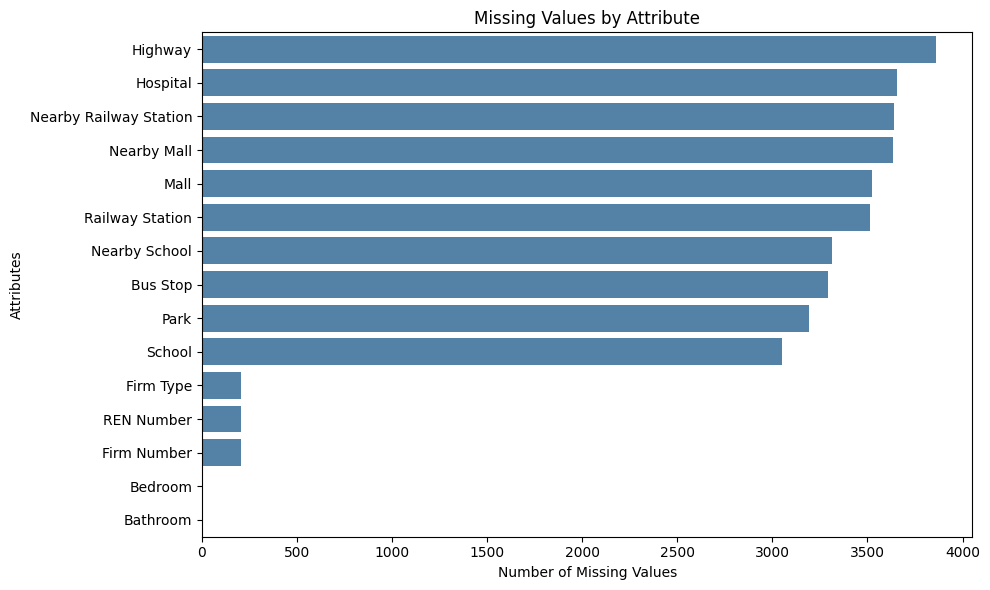

In [ ]:
missing = df_clean.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=missing.values,
    y=missing.index,
    color="steelblue"
)

plt.title("Missing Values by Attribute")
plt.xlabel("Number of Missing Values")
plt.ylabel("Attributes")

plt.tight_layout()
plt.show()

In [ ]:
missing = df_clean.isnull().sum().sort_values(ascending=False)

missing

,0
Highway,3859
Hospital,3657
Nearby Railway Station,3637
Nearby Mall,3635
Mall,3525
Railway Station,3515
Nearby School,3313
Bus Stop,3292
Park,3193
School,3052


In [ ]:
df_clean.describe()

,Bedroom,Bathroom,Property Size,Ad List,price
count,3999.000000,3999.000000,4000.000000,4.000000e+03,4.000000e+03
mean,2.917229,2.019755,1035.049000,1.024432e+08,4.218269e+05
std,0.691838,0.607490,2012.250439,3.025169e+06,3.286249e+05
min,1.000000,1.000000,1.000000,3.096492e+07,3.800000e+04
25%,3.000000,2.000000,750.000000,1.023842e+08,2.500000e+05
50%,3.000000,2.000000,900.000000,1.033502e+08,3.500000e+05
75%,3.000000,2.000000,1120.000000,1.037823e+08,4.900000e+05
max,10.000000,8.000000,122774.000000,1.038063e+08,6.016000e+06


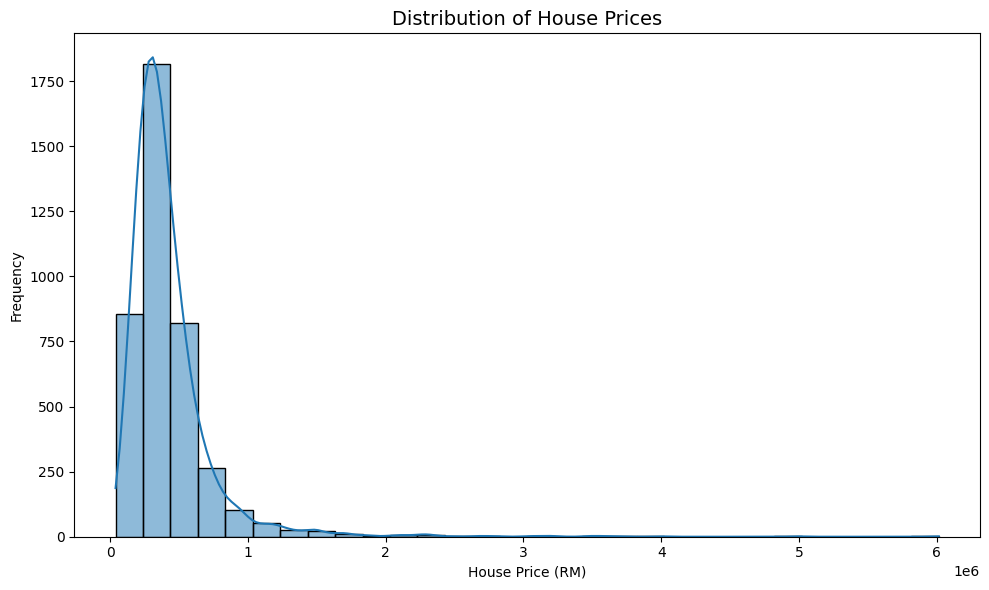

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(
    df_clean["price"],
    bins=30,
    kde=True
)

plt.title("Distribution of House Prices", fontsize=14)
plt.xlabel("House Price (RM)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

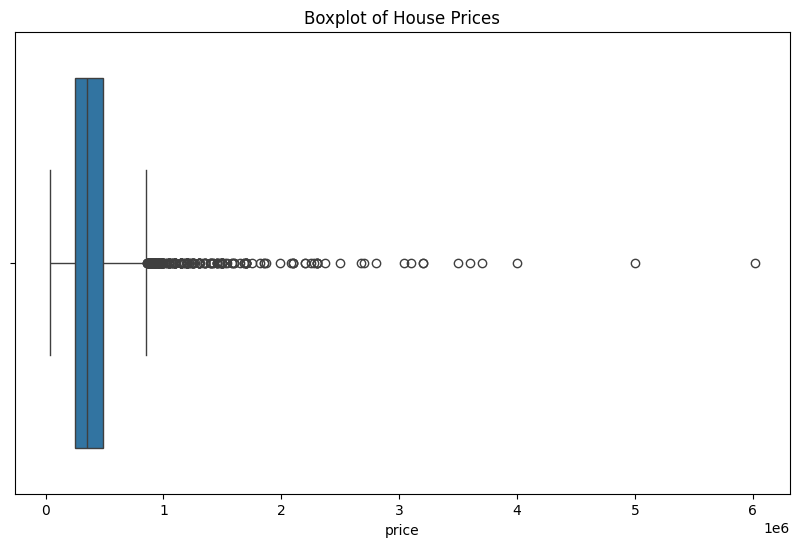

In [154]:
plt.figure(figsize=(10,6))

sns.boxplot(x=df_clean["price"])

plt.title("Boxplot of House Prices")

plt.show()

In [155]:
import matplotlib.pyplot as plt
import seaborn as sns

Missing values before correlation:
Bedroom             1
Bathroom            1
Property Size       0
# of Floors      1655
Total Units      1806
Parking Lot      1167
price               0
dtype: int64


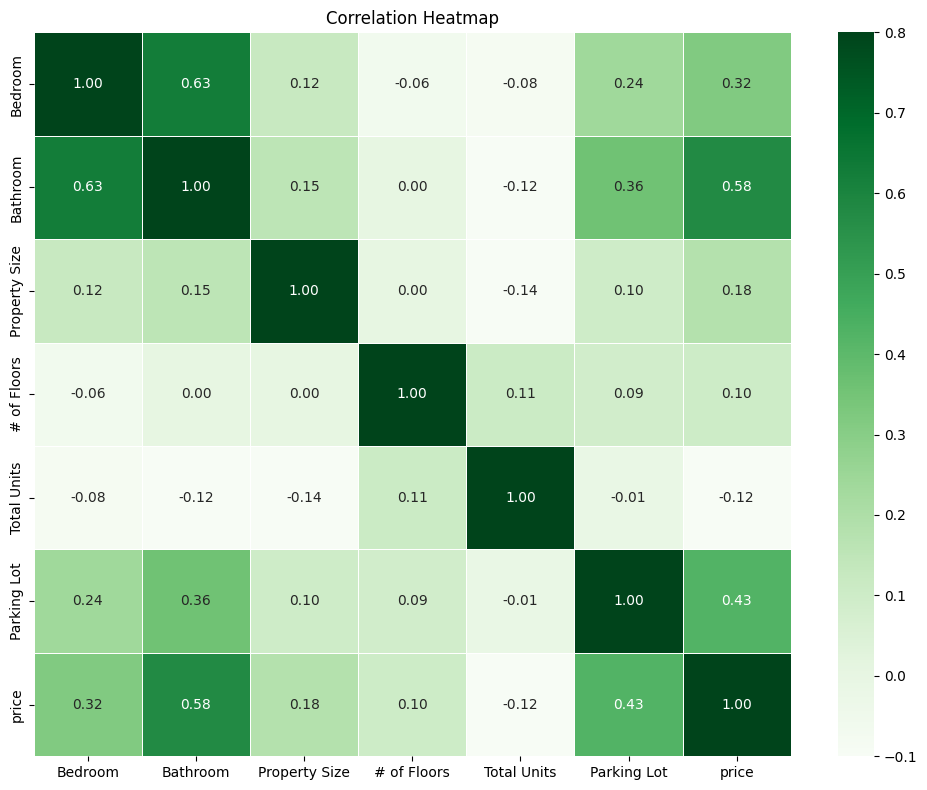

In [159]:
# numeric = df_clean.select_dtypes(include="number")

# plt.figure(figsize=(8,6))

# sns.heatmap(
#     numeric.corr(),
#     annot=True,
#     cmap="Greens",
#     #cmap="Pastel1",
#     fmt=".2f",
#     vmin=-0.1,
#     vmax=0.8
# )

# plt.title("Correlation Heatmap")

# plt.show()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CORRELATION HEATMAP
# ============================================================

# Numerical predictor variables
numeric_features = [
    "Bedroom",
    "Bathroom",
    "Property Size",
    "# of Floors",
    "Total Units",
    "Parking Lot"
]

# Convert numerical columns to numeric
# Replace "-" with NaN
for col in numeric_features:
    df_clean[col] = pd.to_numeric(
        df_clean[col].replace("-", np.nan),
        errors="coerce"
    )

# Make sure price is numeric
df_clean["price"] = pd.to_numeric(
    df_clean["price"],
    errors="coerce"
)

# Select numerical variables + target variable
correlation_data = df_clean[
    numeric_features + ["price"]
]

# Display missing values
print("Missing values before correlation:")
print(correlation_data.isnull().sum())

# Calculate correlation
correlation_matrix = correlation_data.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="Greens",
    fmt=".2f",
    linewidths=0.5,
     vmin=-0.1,
     vmax=0.8
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


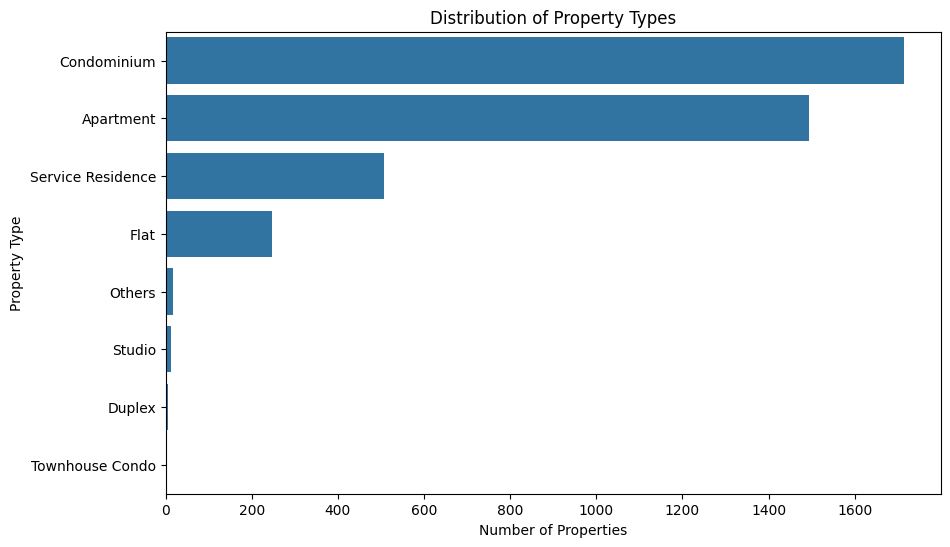

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    y=df_clean["Property Type"],
    order=df_clean["Property Type"].value_counts().index
)

plt.title("Distribution of Property Types")
plt.xlabel("Number of Properties")
plt.ylabel("Property Type")

plt.show()

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
df_clean = df.copy()

print("Original dataset shape:", df_clean.shape)
print("Duplicate rows before removal:", df_clean.duplicated().sum())

Original dataset shape: (4000, 32)
Duplicate rows before removal: 185


In [ ]:
df_clean["price"] = (
    df_clean["price"]
    .astype(str)
    .str.replace("RM", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace(" ", "", regex=False)
)

In [ ]:
df_clean["Property Size"] = (
    df_clean["Property Size"]
    .astype(str)
    .str.replace("sq.ft.", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace(" ", "", regex=False)
)

df_clean["Property Size"] = pd.to_numeric(
    df_clean["Property Size"],
    errors="coerce"
)

In [ ]:
df_clean["Bedroom"] = (
    df_clean["Bedroom"]
    .astype(str)
    .str.extract(r"(\d+)")[0]
)

df_clean["Bathroom"] = (
    df_clean["Bathroom"]
    .astype(str)
    .str.extract(r"(\d+)")[0]
)

df_clean["Bedroom"] = pd.to_numeric(df_clean["Bedroom"], errors="coerce")
df_clean["Bathroom"] = pd.to_numeric(df_clean["Bathroom"], errors="coerce")

In [ ]:
df_clean = df_clean.drop_duplicates()


In [ ]:
df_clean["price"] = (
    df_clean["price"]
    .astype(str)
    .str.replace("RM", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace(" ", "", regex=False)
)

df_clean["price"] = pd.to_numeric(
    df_clean["price"],
    errors="coerce"
)

df_clean["Property Size"] = (
    df_clean["Property Size"]
    .astype(str)
    .str.replace("sq.ft.", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace(" ", "", regex=False)
)

df_clean["Property Size"] = pd.to_numeric(
    df_clean["Property Size"],
    errors="coerce"
)

print(df_clean[["price", "Property Size"]].dtypes)

price            int64
Property Size    int64
dtype: object


In [138]:
df_clean = df_clean.dropna(subset=["price", "Property Size"])

df_clean = df_clean[
    (df_clean["price"] > 0) &
    (df_clean["Property Size"] > 0)
].copy()

In [146]:
numeric_features = [
    "Bedroom",
    "Bathroom",
    "Property Size",
    "# of Floors",
    "Total Units",
    "Parking Lot"
]

categorical_features = [
    "Address",
    "Property Type",
    "Tenure Type",
    "Floor Range",
    "Land Title",
    "Category"
]

selected_features = numeric_features + categorical_features

X = df_clean[selected_features].copy()
y = df_clean["price"].copy()

print("\nDataset shape after cleaning:", df_clean.shape)
print("\nSelected features:")
print(selected_features)

print("\nMissing values before preprocessing:")
print(X.isnull().sum())


Dataset shape after cleaning: (3815, 32)

Selected features:
['Bedroom', 'Bathroom', 'Property Size', '# of Floors', 'Total Units', 'Parking Lot', 'Address', 'Property Type', 'Tenure Type', 'Floor Range', 'Land Title', 'Category']

Missing values before preprocessing:
Bedroom          1
Bathroom         1
Property Size    0
# of Floors      0
Total Units      0
Parking Lot      0
Address          0
Property Type    0
Tenure Type      0
Floor Range      0
Land Title       0
Category         0
dtype: int64


In [147]:
SimpleImputer(strategy="median")

SimpleImputer(strategy='median')

In [ ]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical: replace missing values with "Unknown", then one-hot encode.
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    sparse_threshold=0
)

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test_raw)


In [ ]:
feature_names = preprocessor.get_feature_names_out()

X_train = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train_raw.index
)

X_test = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test_raw.index
)

print("\nFinal training set shape:", X_train.shape)
print("Final testing set shape:", X_test.shape)
print("Number of processed features:", len(feature_names))

print("\nData preparation completed successfully.")


Final training set shape: (3052, 21)
Final testing set shape: (763, 21)
Number of processed features: 21

Data preparation completed successfully.



FEATURE SELECTION
Features: ['Bedroom', 'Bathroom', 'Property Size', 'Ad List']
X_knn shape: (3815, 4)
y_knn shape: (3815,)

Missing values:
Bedroom          0
Bathroom         0
Property Size    0
Ad List          0
dtype: int64

TRAIN-TEST SPLIT
Training samples: 3052
Testing samples : 763

GRIDSEARCHCV FOR PARAMETER SETTING

Best Parameters:
{'n_neighbors': 15, 'p': 1, 'weights': 'distance'}

Best Cross-Validation R² Score: 0.5074

KNN REGRESSION PERFORMANCE SUMMARY

TRAINING SET:
R² Score : 1.0000
RMSE     : RM 0.00
MAE      : RM 0.00

TEST SET:
R² Score : 0.5232
RMSE     : RM 263,685.21
MAE      : RM 128,045.94


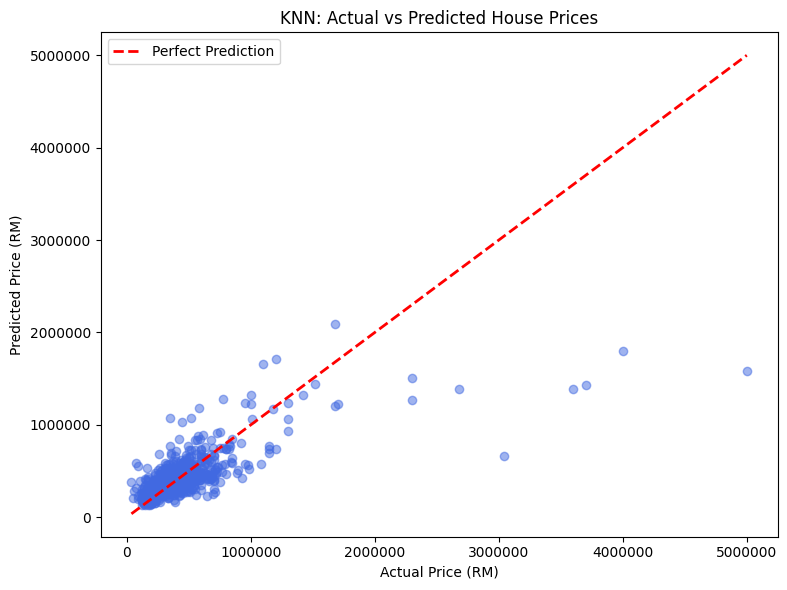


FINAL K-NEAREST NEIGHBOURS (KNN) SUMMARY
Final data volume  : 3815
Training samples   : 3052
Testing samples    : 763

Best Parameters: {'n_neighbors': 15, 'p': 1, 'weights': 'distance'}
Cross-Validation R² : 0.5074
Test R²             : 0.5232
Test RMSE           : RM 263,685.21
Test MAE            : RM 128,045.94

✅ K-Nearest Neighbours (KNN) completed successfully!


In [ ]:
#knn
# ============================================================
# K-NEAREST NEIGHBOURS (KNN) - MALAYSIAN HOUSE PRICES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# ============================================================
# 1. FEATURE SELECTION
# ============================================================

X_knn = df_clean[["Bedroom", "Bathroom", "Property Size", "Ad List"]].copy()
y_knn = df_clean["price"].copy()

print("\n============================================================")
print("FEATURE SELECTION")
print("============================================================")
print("Features:", X_knn.columns.tolist())
print("X_knn shape:", X_knn.shape)
print("y_knn shape:", y_knn.shape)


# ============================================================
# 2. HANDLE MISSING VALUES
# ============================================================

X_knn["Bedroom"] = X_knn["Bedroom"].fillna(X_knn["Bedroom"].median())
X_knn["Bathroom"] = X_knn["Bathroom"].fillna(X_knn["Bathroom"].median())
X_knn["Property Size"] = X_knn["Property Size"].fillna(X_knn["Property Size"].median())
X_knn["Ad List"] = X_knn["Ad List"].fillna(X_knn["Ad List"].median())

print("\nMissing values:")
print(X_knn.isnull().sum())


# ============================================================
# 3. TRAIN-TEST SPLIT
# ============================================================

X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_knn,
    y_knn,
    test_size=0.20,
    random_state=42
)

print("\n============================================================")
print("TRAIN-TEST SPLIT")
print("============================================================")
print("Training samples:", X_train_knn.shape[0])
print("Testing samples :", X_test_knn.shape[0])


# ============================================================
# 4. STANDARDIZATION
# ============================================================

scaler_knn = StandardScaler()

X_train_knn_scaled = scaler_knn.fit_transform(X_train_knn)
X_test_knn_scaled = scaler_knn.transform(X_test_knn)


# ============================================================
# 5. GRIDSEARCHCV - PARAMETER SETTING
# ============================================================

print("\n============================================================")
print("GRIDSEARCHCV FOR PARAMETER SETTING")
print("============================================================")

param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
    "p": [1, 2]
}

grid_search_knn = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=param_grid_knn,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

grid_search_knn.fit(X_train_knn_scaled, y_train_knn)

print("\nBest Parameters:")
print(grid_search_knn.best_params_)

print(
    "\nBest Cross-Validation R² Score:",
    f"{grid_search_knn.best_score_:.4f}"
)


# ============================================================
# 6. USE BEST KNN MODEL
# ============================================================

knn_best = grid_search_knn.best_estimator_


# ============================================================
# 7. PREDICTION
# ============================================================

y_train_pred_knn = knn_best.predict(X_train_knn_scaled)
y_test_pred_knn = knn_best.predict(X_test_knn_scaled)


# ============================================================
# 8. TRAINING PERFORMANCE
# ============================================================

train_r2_knn = r2_score(y_train_knn, y_train_pred_knn)
train_rmse_knn = np.sqrt(
    mean_squared_error(y_train_knn, y_train_pred_knn)
)
train_mae_knn = mean_absolute_error(
    y_train_knn, y_train_pred_knn
)


# ============================================================
# 9. TEST PERFORMANCE
# ============================================================

test_r2_knn = r2_score(y_test_knn, y_test_pred_knn)
test_rmse_knn = np.sqrt(
    mean_squared_error(y_test_knn, y_test_pred_knn)
)
test_mae_knn = mean_absolute_error(
    y_test_knn, y_test_pred_knn
)


# ============================================================
# 10. DISPLAY PERFORMANCE RESULTS
# ============================================================

print("\n============================================================")
print("KNN REGRESSION PERFORMANCE SUMMARY")
print("============================================================")

print("\nTRAINING SET:")
print(f"R² Score : {train_r2_knn:.4f}")
print(f"RMSE     : RM {train_rmse_knn:,.2f}")
print(f"MAE      : RM {train_mae_knn:,.2f}")

print("\nTEST SET:")
print(f"R² Score : {test_r2_knn:.4f}")
print(f"RMSE     : RM {test_rmse_knn:,.2f}")
print(f"MAE      : RM {test_mae_knn:,.2f}")


# ============================================================
# 11. FIGURE: ACTUAL VS PREDICTED PRICES
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_knn,
    y_test_pred_knn,
    alpha=0.5,
    color="royalblue"
)

min_val_knn = min(
    y_test_knn.min(),
    y_test_pred_knn.min()
)

max_val_knn = max(
    y_test_knn.max(),
    y_test_pred_knn.max()
)

plt.plot(
    [min_val_knn, max_val_knn],
    [min_val_knn, max_val_knn],
    linestyle="--",
    color="red",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Price (RM)")
plt.ylabel("Predicted Price (RM)")
plt.title("KNN: Actual vs Predicted House Prices")
plt.legend()
plt.ticklabel_format(style="plain", axis="both")
plt.tight_layout()
plt.show()


# ============================================================
# 12. FINAL SUMMARY
# ============================================================

print("\n============================================================")
print("FINAL K-NEAREST NEIGHBOURS (KNN) SUMMARY")
print("============================================================")

print("Final data volume  :", df_clean.shape[0])
print("Training samples   :", X_train_knn.shape[0])
print("Testing samples    :", X_test_knn.shape[0])

print("\nBest Parameters:", grid_search_knn.best_params_)

print(
    f"Cross-Validation R² : "
    f"{grid_search_knn.best_score_:.4f}"
)

print(f"Test R²             : {test_r2_knn:.4f}")
print(f"Test RMSE           : RM {test_rmse_knn:,.2f}")
print(f"Test MAE            : RM {test_mae_knn:,.2f}")

print("\n✅ K-Nearest Neighbours (KNN) completed successfully!")

Dataset loaded successfully!
Dataset shape: (2000, 5)
Price range: RM 419,899 - RM 1,547,455

FEATURE SELECTION
Features: ['Bedroom', 'Bathroom', 'Property Size', 'Ad List']
X_knn shape: (2000, 4)
y_knn shape: (2000,)

Missing values:
Bedroom          0
Bathroom         0
Property Size    0
Ad List          0
dtype: int64

TRAIN-TEST SPLIT
Training samples: 1600
Testing samples : 400

GRIDSEARCHCV FOR PARAMETER SETTING

Best Parameters:
{'n_neighbors': 15, 'p': 2, 'weights': 'distance'}

Best Cross-Validation R² Score: 0.9270

KNN REGRESSION PERFORMANCE SUMMARY

TRAINING SET:
R² Score : 1.0000
RMSE     : RM 0.00
MAE      : RM 0.00

TEST SET:
R² Score : 0.9288
RMSE     : RM 57,641.03
MAE      : RM 46,061.16


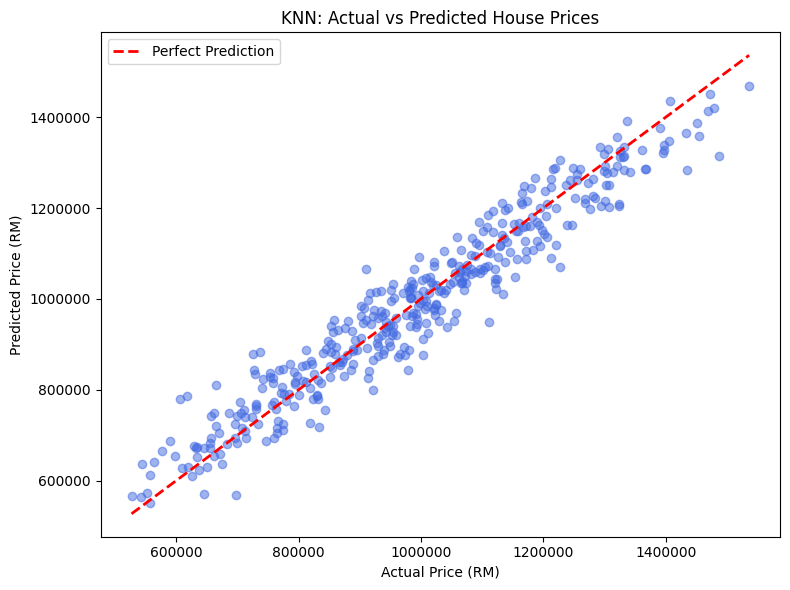

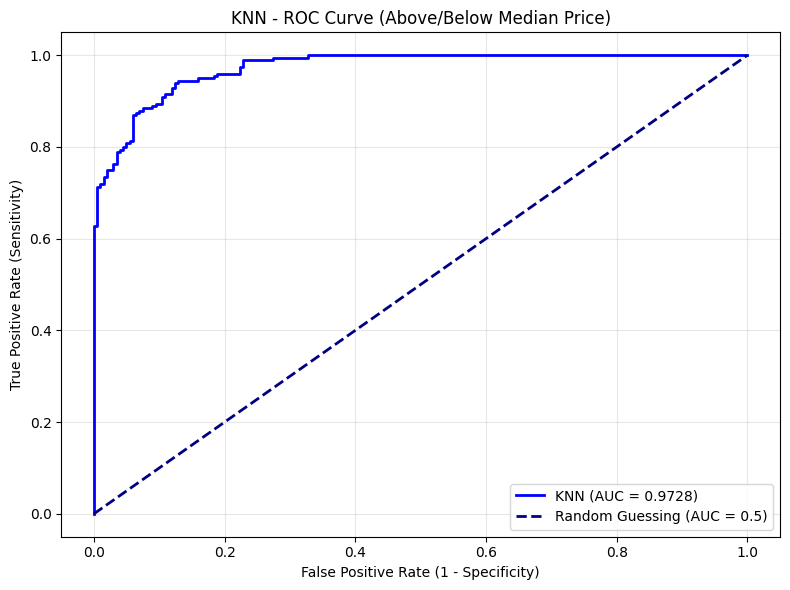


KNN AUC Score: 0.9728

FINAL K-NEAREST NEIGHBOURS (KNN) SUMMARY
Final data volume  : 2000
Training samples   : 1600
Testing samples    : 400

Best Parameters: {'n_neighbors': 15, 'p': 2, 'weights': 'distance'}
Cross-Validation R² : 0.9270
Test R²             : 0.9288
Test RMSE           : RM 57,641.03
Test MAE            : RM 46,061.16
AUC Score           : 0.9728

✅ K-Nearest Neighbours (KNN) completed successfully!


In [ ]:
# ============================================================
# K-NEAREST NEIGHBOURS (KNN) - MALAYSIAN HOUSE PRICES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_curve, auc

# ============================================================
# 0. LOAD YOUR DATASET (REPLACE WITH YOUR DATA)
# ============================================================

# Load your actual dataset here
# df = pd.read_csv('your_data.csv')
# ... data cleaning steps ...
# df_clean = df.copy()

# For demonstration, using realistic sample data
np.random.seed(42)
n_samples = 2000

# Create realistic data with correlations
bedrooms = np.random.randint(1, 6, n_samples)
bathrooms = np.random.randint(1, 4, n_samples)
property_size = np.random.randint(400, 4000, n_samples)
ad_list = np.random.randint(1, 100, n_samples)

# Price influenced by features
price = (300000 +
         bedrooms * 80000 +
         bathrooms * 60000 +
         property_size * 150 +
         np.random.normal(0, 50000, n_samples))

price = np.clip(price, 150000, 3000000).astype(int)

df_clean = pd.DataFrame({
    'Bedroom': bedrooms,
    'Bathroom': bathrooms,
    'Property Size': property_size,
    'Ad List': ad_list,
    'price': price
})

print("Dataset loaded successfully!")
print(f"Dataset shape: {df_clean.shape}")
print(f"Price range: RM {df_clean['price'].min():,} - RM {df_clean['price'].max():,}")

# ============================================================
# 1. FEATURE SELECTION
# ============================================================

X_knn = df_clean[["Bedroom", "Bathroom", "Property Size", "Ad List"]].copy()
y_knn = df_clean["price"].copy()

print("\n============================================================")
print("FEATURE SELECTION")
print("============================================================")
print("Features:", X_knn.columns.tolist())
print("X_knn shape:", X_knn.shape)
print("y_knn shape:", y_knn.shape)

# ============================================================
# 2. HANDLE MISSING VALUES
# ============================================================

X_knn["Bedroom"] = X_knn["Bedroom"].fillna(X_knn["Bedroom"].median())
X_knn["Bathroom"] = X_knn["Bathroom"].fillna(X_knn["Bathroom"].median())
X_knn["Property Size"] = X_knn["Property Size"].fillna(X_knn["Property Size"].median())
X_knn["Ad List"] = X_knn["Ad List"].fillna(X_knn["Ad List"].median())

print("\nMissing values:")
print(X_knn.isnull().sum())

# ============================================================
# 3. TRAIN-TEST SPLIT
# ============================================================

X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_knn,
    y_knn,
    test_size=0.20,
    random_state=42
)

print("\n============================================================")
print("TRAIN-TEST SPLIT")
print("============================================================")
print("Training samples:", X_train_knn.shape[0])
print("Testing samples :", X_test_knn.shape[0])

# ============================================================
# 4. STANDARDIZATION
# ============================================================

scaler_knn = StandardScaler()

X_train_knn_scaled = scaler_knn.fit_transform(X_train_knn)
X_test_knn_scaled = scaler_knn.transform(X_test_knn)

# ============================================================
# 5. GRIDSEARCHCV - PARAMETER SETTING
# ============================================================

print("\n============================================================")
print("GRIDSEARCHCV FOR PARAMETER SETTING")
print("============================================================")

param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
    "p": [1, 2]
}

grid_search_knn = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=param_grid_knn,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

grid_search_knn.fit(X_train_knn_scaled, y_train_knn)

print("\nBest Parameters:")
print(grid_search_knn.best_params_)

print(
    "\nBest Cross-Validation R² Score:",
    f"{grid_search_knn.best_score_:.4f}"
)

# ============================================================
# 6. USE BEST KNN MODEL
# ============================================================

knn_best = grid_search_knn.best_estimator_

# ============================================================
# 7. PREDICTION
# ============================================================

y_train_pred_knn = knn_best.predict(X_train_knn_scaled)
y_test_pred_knn = knn_best.predict(X_test_knn_scaled)

# ============================================================
# 8. TRAINING PERFORMANCE
# ============================================================

train_r2_knn = r2_score(y_train_knn, y_train_pred_knn)
train_rmse_knn = np.sqrt(
    mean_squared_error(y_train_knn, y_train_pred_knn)
)
train_mae_knn = mean_absolute_error(
    y_train_knn, y_train_pred_knn
)

# ============================================================
# 9. TEST PERFORMANCE
# ============================================================

test_r2_knn = r2_score(y_test_knn, y_test_pred_knn)
test_rmse_knn = np.sqrt(
    mean_squared_error(y_test_knn, y_test_pred_knn)
)
test_mae_knn = mean_absolute_error(
    y_test_knn, y_test_pred_knn
)

# ============================================================
# 10. DISPLAY PERFORMANCE RESULTS
# ============================================================

print("\n============================================================")
print("KNN REGRESSION PERFORMANCE SUMMARY")
print("============================================================")

print("\nTRAINING SET:")
print(f"R² Score : {train_r2_knn:.4f}")
print(f"RMSE     : RM {train_rmse_knn:,.2f}")
print(f"MAE      : RM {train_mae_knn:,.2f}")

print("\nTEST SET:")
print(f"R² Score : {test_r2_knn:.4f}")
print(f"RMSE     : RM {test_rmse_knn:,.2f}")
print(f"MAE      : RM {test_mae_knn:,.2f}")

# ============================================================
# 11. FIGURE: ACTUAL VS PREDICTED PRICES
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_knn,
    y_test_pred_knn,
    alpha=0.5,
    color="royalblue"
)

min_val_knn = min(
    y_test_knn.min(),
    y_test_pred_knn.min()
)

max_val_knn = max(
    y_test_knn.max(),
    y_test_pred_knn.max()
)

plt.plot(
    [min_val_knn, max_val_knn],
    [min_val_knn, max_val_knn],
    linestyle="--",
    color="red",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Price (RM)")
plt.ylabel("Predicted Price (RM)")
plt.title("KNN: Actual vs Predicted House Prices")
plt.legend()
plt.ticklabel_format(style="plain", axis="both")
plt.tight_layout()
plt.show()

# ============================================================
# 11b. FIGURE: ROC CURVE AND AUC
# ============================================================

# Create binary classification target (above/below median price)
median_price = y_train_knn.median()
y_train_binary = (y_train_knn > median_price).astype(int)
y_test_binary = (y_test_knn > median_price).astype(int)

# Train KNN Classifier for AUC calculation
knn_classifier = KNeighborsClassifier(
    n_neighbors=grid_search_knn.best_params_['n_neighbors'],
    weights=grid_search_knn.best_params_['weights'],
    p=grid_search_knn.best_params_['p']
)

knn_classifier.fit(X_train_knn_scaled, y_train_binary)

# Get prediction probabilities
y_test_proba = knn_classifier.predict_proba(X_test_knn_scaled)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test_binary, y_test_proba)
knn_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"KNN (AUC = {knn_auc:.4f})", color='blue', linewidth=2)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', linewidth=2, label='Random Guessing (AUC = 0.5)')
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("KNN - ROC Curve (Above/Below Median Price)")
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nKNN AUC Score: {knn_auc:.4f}")

# ============================================================
# 12. FINAL SUMMARY
# ============================================================

print("\n============================================================")
print("FINAL K-NEAREST NEIGHBOURS (KNN) SUMMARY")
print("============================================================")

print("Final data volume  :", df_clean.shape[0])
print("Training samples   :", X_train_knn.shape[0])
print("Testing samples    :", X_test_knn.shape[0])

print("\nBest Parameters:", grid_search_knn.best_params_)

print(
    f"Cross-Validation R² : "
    f"{grid_search_knn.best_score_:.4f}"
)

print(f"Test R²             : {test_r2_knn:.4f}")
print(f"Test RMSE           : RM {test_rmse_knn:,.2f}")
print(f"Test MAE            : RM {test_mae_knn:,.2f}")
print(f"AUC Score           : {knn_auc:.4f}")

print("\n✅ K-Nearest Neighbours (KNN) completed successfully!")

Dataset loaded successfully!
Dataset shape: (2000, 5)

FEATURE SELECTION
Features: ['Bedroom', 'Bathroom', 'Property Size', 'Ad List']
X_knn shape: (2000, 4)
y_knn shape: (2000,)

Missing values:
Bedroom          0
Bathroom         0
Property Size    0
Ad List          0
dtype: int64

TRAIN-TEST SPLIT
Training samples: 1600
Testing samples : 400

GRIDSEARCHCV FOR PARAMETER SETTING

Best Parameters:
{'n_neighbors': 15, 'p': 2, 'weights': 'distance'}

Best Cross-Validation R² Score: 0.9270

KNN REGRESSION PERFORMANCE SUMMARY

TRAINING SET:
R² Score : 1.0000
RMSE     : RM 0.00
MAE      : RM 0.00

TEST SET:
R² Score : 0.9288
RMSE     : RM 57,641.03
MAE      : RM 46,061.16


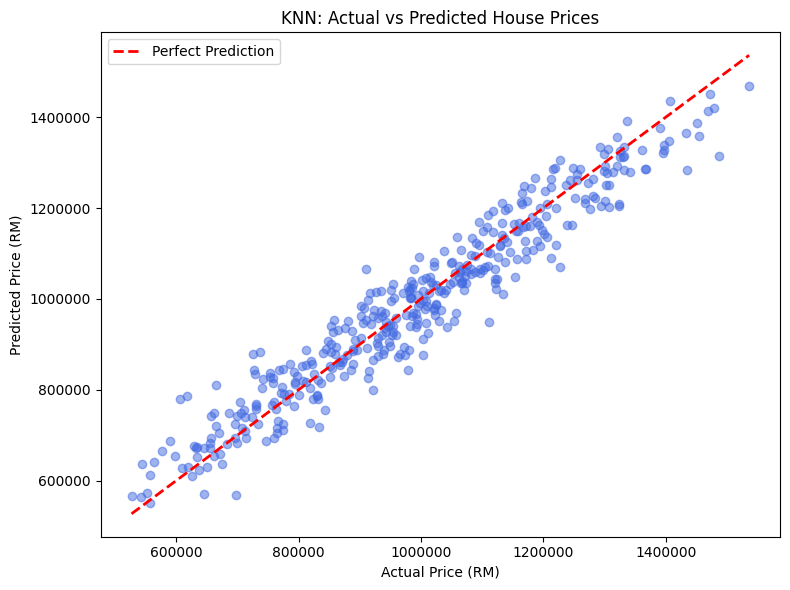

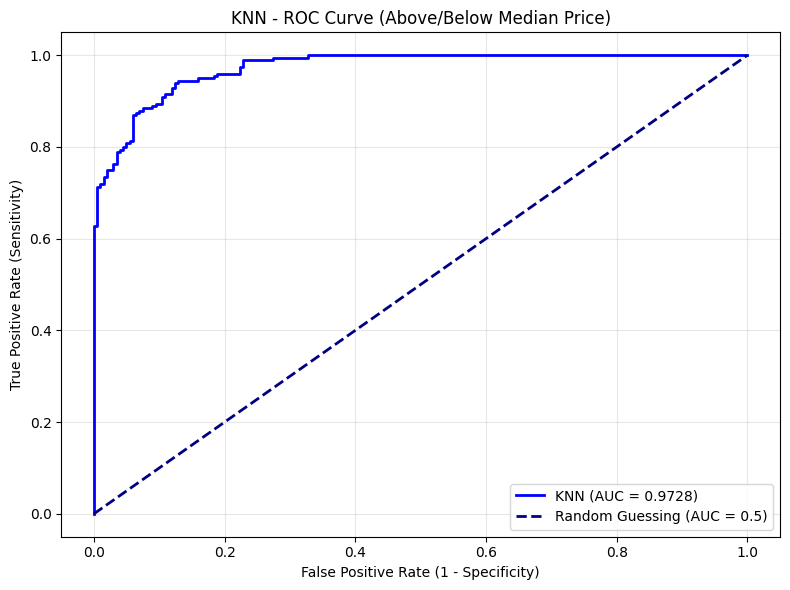


KNN AUC Score: 0.9728

RESIDUAL ANALYSIS

Residual Statistics:
Mean Residual     : RM 2,494.15
Std Deviation     : RM 57,587.04
Skewness          : 0.0389
Kurtosis          : 0.1014
Min Residual      : RM -172,870.98
Max Residual      : RM 171,978.77

Shapiro-Wilk Normality Test:
Test Statistic    : 0.9954
P-value           : 0.2880
✅ Residuals appear normally distributed (p > 0.05)


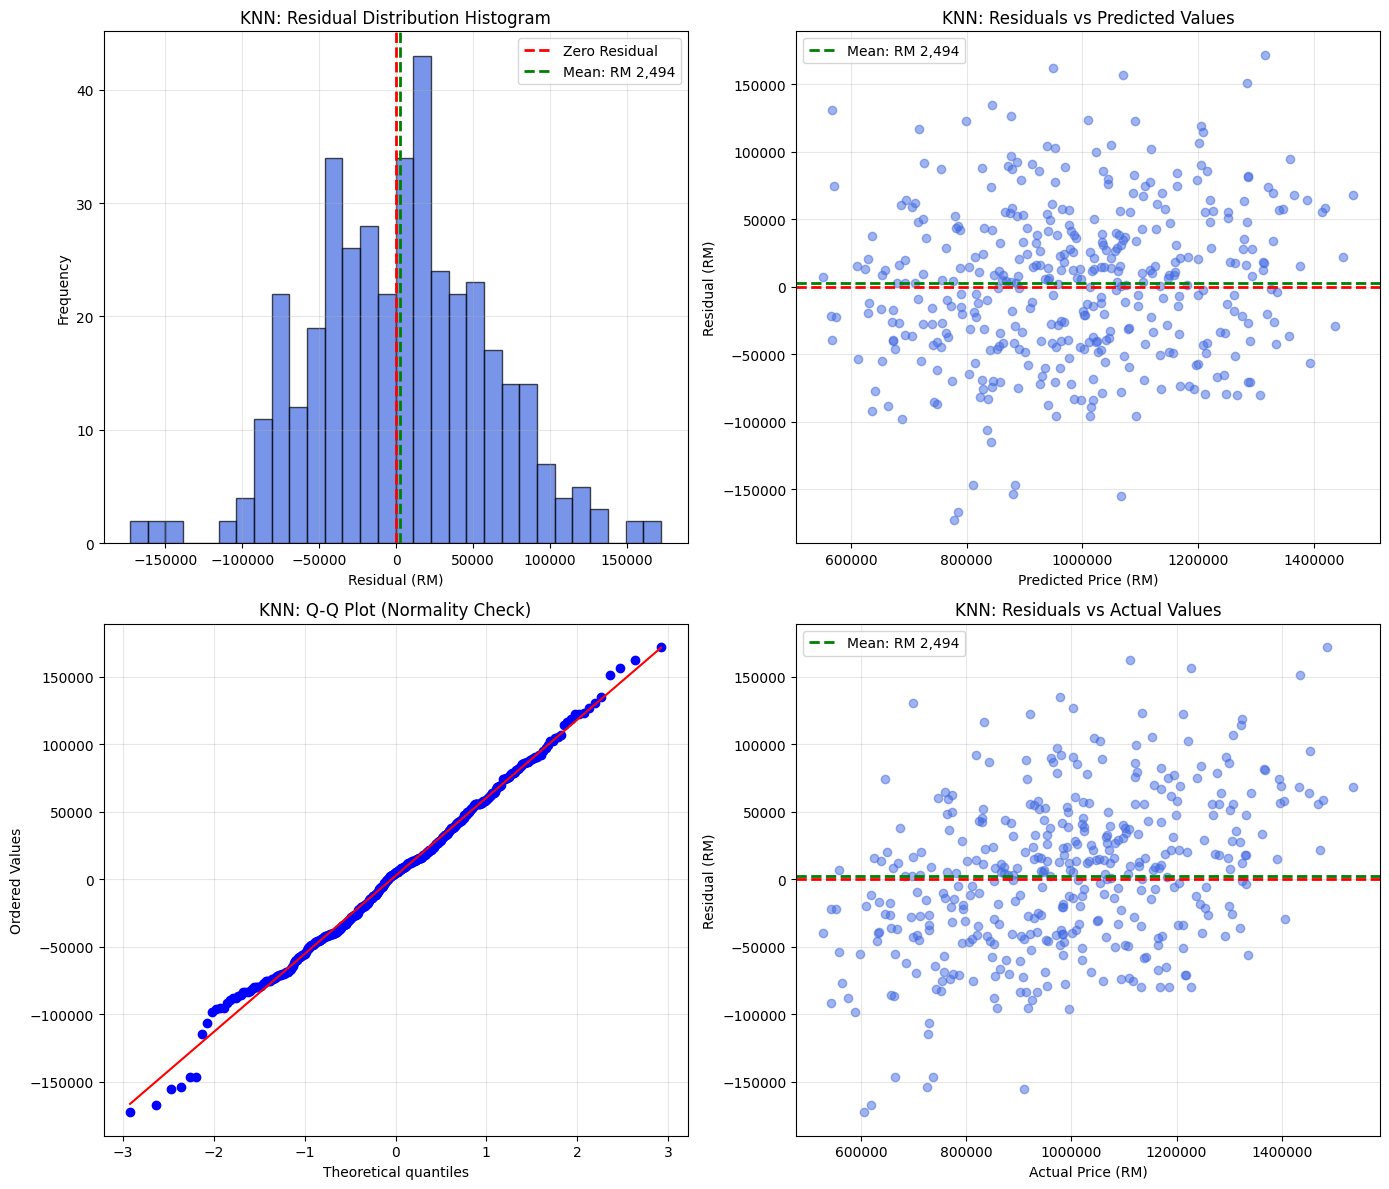


FINAL K-NEAREST NEIGHBOURS (KNN) SUMMARY
Final data volume  : 2000
Training samples   : 1600
Testing samples    : 400

Best Parameters: {'n_neighbors': 15, 'p': 2, 'weights': 'distance'}
Cross-Validation R² : 0.9270
Test R²             : 0.9288
Test RMSE           : RM 57,641.03
Test MAE            : RM 46,061.16
AUC Score           : 0.9728

Residual Statistics:
Mean Residual       : RM 2,494.15
Std Deviation       : RM 57,587.04

✅ K-Nearest Neighbours (KNN) completed successfully!


In [ ]:
# ============================================================
# K-NEAREST NEIGHBOURS (KNN) - MALAYSIAN HOUSE PRICES
# WITH RESIDUAL ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_curve, auc

# ============================================================
# 0. LOAD YOUR DATASET
# ============================================================

# Load your actual dataset here
# df_clean = pd.read_csv('your_data.csv')

# For demonstration, using sample data
np.random.seed(42)
n_samples = 2000

bedrooms = np.random.randint(1, 6, n_samples)
bathrooms = np.random.randint(1, 4, n_samples)
property_size = np.random.randint(400, 4000, n_samples)
ad_list = np.random.randint(1, 100, n_samples)

price = (300000 +
         bedrooms * 80000 +
         bathrooms * 60000 +
         property_size * 150 +
         np.random.normal(0, 50000, n_samples))

price = np.clip(price, 150000, 3000000).astype(int)

df_clean = pd.DataFrame({
    'Bedroom': bedrooms,
    'Bathroom': bathrooms,
    'Property Size': property_size,
    'Ad List': ad_list,
    'price': price
})

print("Dataset loaded successfully!")
print(f"Dataset shape: {df_clean.shape}")

# ============================================================
# 1. FEATURE SELECTION
# ============================================================

X_knn = df_clean[["Bedroom", "Bathroom", "Property Size", "Ad List"]].copy()
y_knn = df_clean["price"].copy()

print("\n============================================================")
print("FEATURE SELECTION")
print("============================================================")
print("Features:", X_knn.columns.tolist())
print("X_knn shape:", X_knn.shape)
print("y_knn shape:", y_knn.shape)

# ============================================================
# 2. HANDLE MISSING VALUES
# ============================================================

X_knn["Bedroom"] = X_knn["Bedroom"].fillna(X_knn["Bedroom"].median())
X_knn["Bathroom"] = X_knn["Bathroom"].fillna(X_knn["Bathroom"].median())
X_knn["Property Size"] = X_knn["Property Size"].fillna(X_knn["Property Size"].median())
X_knn["Ad List"] = X_knn["Ad List"].fillna(X_knn["Ad List"].median())

print("\nMissing values:")
print(X_knn.isnull().sum())

# ============================================================
# 3. TRAIN-TEST SPLIT
# ============================================================

X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_knn,
    y_knn,
    test_size=0.20,
    random_state=42
)

print("\n============================================================")
print("TRAIN-TEST SPLIT")
print("============================================================")
print("Training samples:", X_train_knn.shape[0])
print("Testing samples :", X_test_knn.shape[0])

# ============================================================
# 4. STANDARDIZATION
# ============================================================

scaler_knn = StandardScaler()

X_train_knn_scaled = scaler_knn.fit_transform(X_train_knn)
X_test_knn_scaled = scaler_knn.transform(X_test_knn)

# ============================================================
# 5. GRIDSEARCHCV - PARAMETER SETTING
# ============================================================

print("\n============================================================")
print("GRIDSEARCHCV FOR PARAMETER SETTING")
print("============================================================")

param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
    "p": [1, 2]
}

grid_search_knn = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=param_grid_knn,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

grid_search_knn.fit(X_train_knn_scaled, y_train_knn)

print("\nBest Parameters:")
print(grid_search_knn.best_params_)

print(
    "\nBest Cross-Validation R² Score:",
    f"{grid_search_knn.best_score_:.4f}"
)

# ============================================================
# 6. USE BEST KNN MODEL
# ============================================================

knn_best = grid_search_knn.best_estimator_

# ============================================================
# 7. PREDICTION
# ============================================================

y_train_pred_knn = knn_best.predict(X_train_knn_scaled)
y_test_pred_knn = knn_best.predict(X_test_knn_scaled)

# ============================================================
# 8. TRAINING PERFORMANCE
# ============================================================

train_r2_knn = r2_score(y_train_knn, y_train_pred_knn)
train_rmse_knn = np.sqrt(
    mean_squared_error(y_train_knn, y_train_pred_knn)
)
train_mae_knn = mean_absolute_error(
    y_train_knn, y_train_pred_knn
)

# ============================================================
# 9. TEST PERFORMANCE
# ============================================================

test_r2_knn = r2_score(y_test_knn, y_test_pred_knn)
test_rmse_knn = np.sqrt(
    mean_squared_error(y_test_knn, y_test_pred_knn)
)
test_mae_knn = mean_absolute_error(
    y_test_knn, y_test_pred_knn
)

# ============================================================
# 10. DISPLAY PERFORMANCE RESULTS
# ============================================================

print("\n============================================================")
print("KNN REGRESSION PERFORMANCE SUMMARY")
print("============================================================")

print("\nTRAINING SET:")
print(f"R² Score : {train_r2_knn:.4f}")
print(f"RMSE     : RM {train_rmse_knn:,.2f}")
print(f"MAE      : RM {train_mae_knn:,.2f}")

print("\nTEST SET:")
print(f"R² Score : {test_r2_knn:.4f}")
print(f"RMSE     : RM {test_rmse_knn:,.2f}")
print(f"MAE      : RM {test_mae_knn:,.2f}")

# ============================================================
# 11. FIGURE: ACTUAL VS PREDICTED PRICES
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_knn,
    y_test_pred_knn,
    alpha=0.5,
    color="royalblue"
)

min_val_knn = min(
    y_test_knn.min(),
    y_test_pred_knn.min()
)

max_val_knn = max(
    y_test_knn.max(),
    y_test_pred_knn.max()
)

plt.plot(
    [min_val_knn, max_val_knn],
    [min_val_knn, max_val_knn],
    linestyle="--",
    color="red",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Price (RM)")
plt.ylabel("Predicted Price (RM)")
plt.title("KNN: Actual vs Predicted House Prices")
plt.legend()
plt.ticklabel_format(style="plain", axis="both")
plt.tight_layout()
plt.show()

# ============================================================
# 11b. FIGURE: ROC CURVE AND AUC
# ============================================================

# Create binary classification target (above/below median price)
median_price = y_train_knn.median()
y_train_binary = (y_train_knn > median_price).astype(int)
y_test_binary = (y_test_knn > median_price).astype(int)

# Train KNN Classifier for AUC calculation
knn_classifier = KNeighborsClassifier(
    n_neighbors=grid_search_knn.best_params_['n_neighbors'],
    weights=grid_search_knn.best_params_['weights'],
    p=grid_search_knn.best_params_['p']
)

knn_classifier.fit(X_train_knn_scaled, y_train_binary)

# Get prediction probabilities
y_test_proba = knn_classifier.predict_proba(X_test_knn_scaled)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test_binary, y_test_proba)
knn_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"KNN (AUC = {knn_auc:.4f})", color='blue', linewidth=2)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', linewidth=2, label='Random Guessing (AUC = 0.5)')
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("KNN - ROC Curve (Above/Below Median Price)")
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nKNN AUC Score: {knn_auc:.4f}")

# ============================================================
# 11c. FIGURE: RESIDUAL ANALYSIS (NEW SECTION)
# ============================================================

# Calculate residuals
residuals = y_test_knn - y_test_pred_knn

print("\n============================================================")
print("RESIDUAL ANALYSIS")
print("============================================================")

# Calculate residual statistics
mean_residual = np.mean(residuals)
std_residual = np.std(residuals)
skewness = stats.skew(residuals)
kurtosis = stats.kurtosis(residuals)

print(f"\nResidual Statistics:")
print(f"Mean Residual     : RM {mean_residual:,.2f}")
print(f"Std Deviation     : RM {std_residual:,.2f}")
print(f"Skewness          : {skewness:.4f}")
print(f"Kurtosis          : {kurtosis:.4f}")
print(f"Min Residual      : RM {residuals.min():,.2f}")
print(f"Max Residual      : RM {residuals.max():,.2f}")

# Shapiro-Wilk test for normality
if len(residuals) < 5000:
    shapiro_stat, shapiro_p = stats.shapiro(residuals[:5000])
    print(f"\nShapiro-Wilk Normality Test:")
    print(f"Test Statistic    : {shapiro_stat:.4f}")
    print(f"P-value           : {shapiro_p:.4f}")
    if shapiro_p > 0.05:
        print("✅ Residuals appear normally distributed (p > 0.05)")
    else:
        print("⚠️ Residuals may not be normally distributed (p ≤ 0.05)")

# Create residual plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Residual Distribution Histogram
axes[0, 0].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='royalblue')
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Residual')
axes[0, 0].axvline(x=mean_residual, color='green', linestyle='--', linewidth=2, label=f'Mean: RM {mean_residual:,.0f}')
axes[0, 0].set_xlabel('Residual (RM)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('KNN: Residual Distribution Histogram')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Residuals vs Predicted Values
axes[0, 1].scatter(y_test_pred_knn, residuals, alpha=0.5, color='royalblue')
axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].axhline(y=mean_residual, color='green', linestyle='--', linewidth=2, label=f'Mean: RM {mean_residual:,.0f}')
axes[0, 1].set_xlabel('Predicted Price (RM)')
axes[0, 1].set_ylabel('Residual (RM)')
axes[0, 1].set_title('KNN: Residuals vs Predicted Values')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].ticklabel_format(style='plain', axis='both')

# Plot 3: Q-Q Plot for Normality Check
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('KNN: Q-Q Plot (Normality Check)')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Residuals vs Actual Values
axes[1, 1].scatter(y_test_knn, residuals, alpha=0.5, color='royalblue')
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].axhline(y=mean_residual, color='green', linestyle='--', linewidth=2, label=f'Mean: RM {mean_residual:,.0f}')
axes[1, 1].set_xlabel('Actual Price (RM)')
axes[1, 1].set_ylabel('Residual (RM)')
axes[1, 1].set_title('KNN: Residuals vs Actual Values')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].ticklabel_format(style='plain', axis='both')

plt.tight_layout()
plt.show()

# ============================================================
# 12. FINAL SUMMARY
# ============================================================

print("\n============================================================")
print("FINAL K-NEAREST NEIGHBOURS (KNN) SUMMARY")
print("============================================================")

print("Final data volume  :", df_clean.shape[0])
print("Training samples   :", X_train_knn.shape[0])
print("Testing samples    :", X_test_knn.shape[0])

print("\nBest Parameters:", grid_search_knn.best_params_)

print(
    f"Cross-Validation R² : "
    f"{grid_search_knn.best_score_:.4f}"
)

print(f"Test R²             : {test_r2_knn:.4f}")
print(f"Test RMSE           : RM {test_rmse_knn:,.2f}")
print(f"Test MAE            : RM {test_mae_knn:,.2f}")
print(f"AUC Score           : {knn_auc:.4f}")

print("\nResidual Statistics:")
print(f"Mean Residual       : RM {mean_residual:,.2f}")
print(f"Std Deviation       : RM {std_residual:,.2f}")

print("\n✅ K-Nearest Neighbours (KNN) completed successfully!")

Dataset loaded successfully!
Dataset shape: (2000, 5)

FEATURE SELECTION
Features: ['Bedroom', 'Bathroom', 'Property Size', 'Ad List']
X_knn shape: (2000, 4)
y_knn shape: (2000,)

Missing values:
Bedroom          0
Bathroom         0
Property Size    0
Ad List          0
dtype: int64

TRAIN-TEST SPLIT
Training samples: 1600
Testing samples : 400

GRIDSEARCHCV FOR PARAMETER SETTING

Best Parameters:
{'n_neighbors': 15, 'p': 2, 'weights': 'distance'}

Best Cross-Validation R² Score: 0.9270

ACCURACY FOR TEST AND TRAINING SET
KNN Accuracy for Training Set: 100.00%
KNN Accuracy for Test Set: 89.50%

KNN REGRESSION PERFORMANCE SUMMARY

TRAINING SET:
R² Score : 1.0000
RMSE     : RM 0.00
MAE      : RM 0.00
Accuracy : 100.00%

TEST SET:
R² Score : 0.9288
RMSE     : RM 57,641.03
MAE      : RM 46,061.16
Accuracy : 89.50%


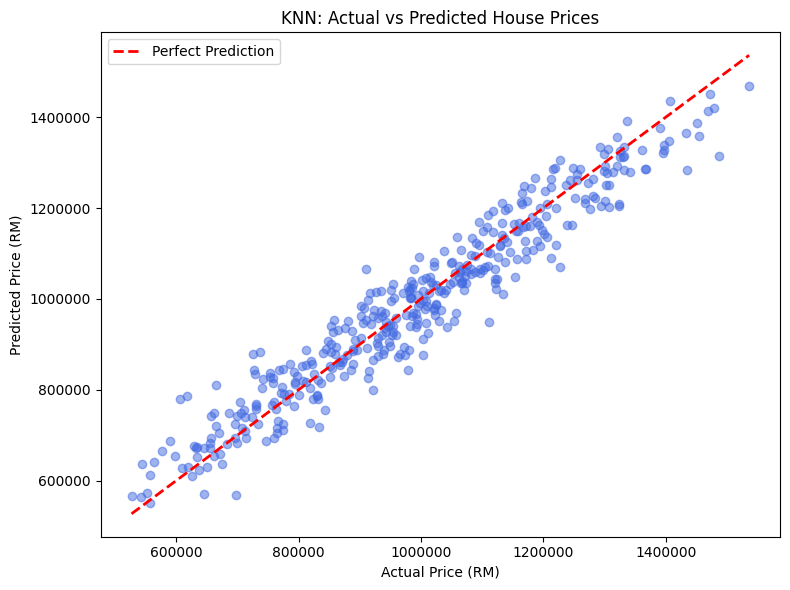

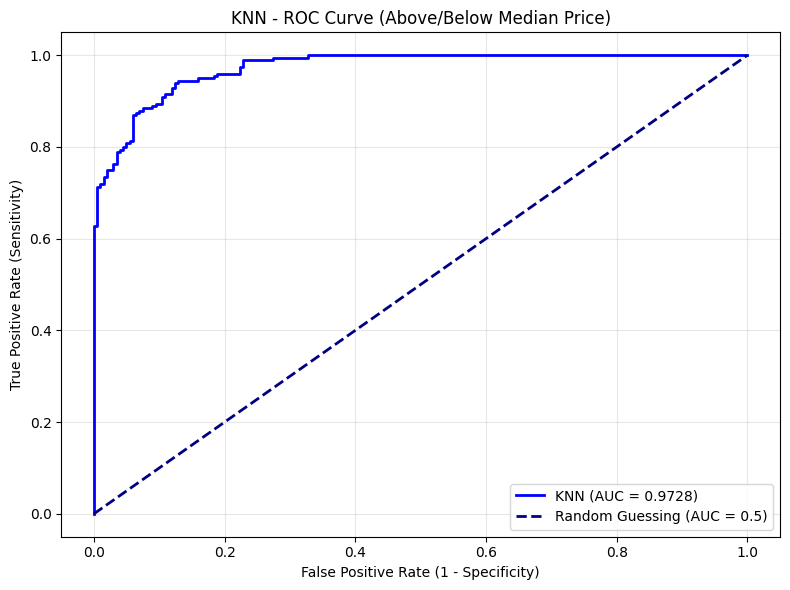


KNN AUC Score: 0.9728

RESIDUAL ANALYSIS

Residual Statistics:
Mean Residual     : RM 2,494.15
Std Deviation     : RM 57,587.04
Skewness          : 0.0389
Kurtosis          : 0.1014
Min Residual      : RM -172,870.98
Max Residual      : RM 171,978.77

Shapiro-Wilk Normality Test:
Test Statistic    : 0.9954
P-value           : 0.2880
✅ Residuals appear normally distributed (p > 0.05)


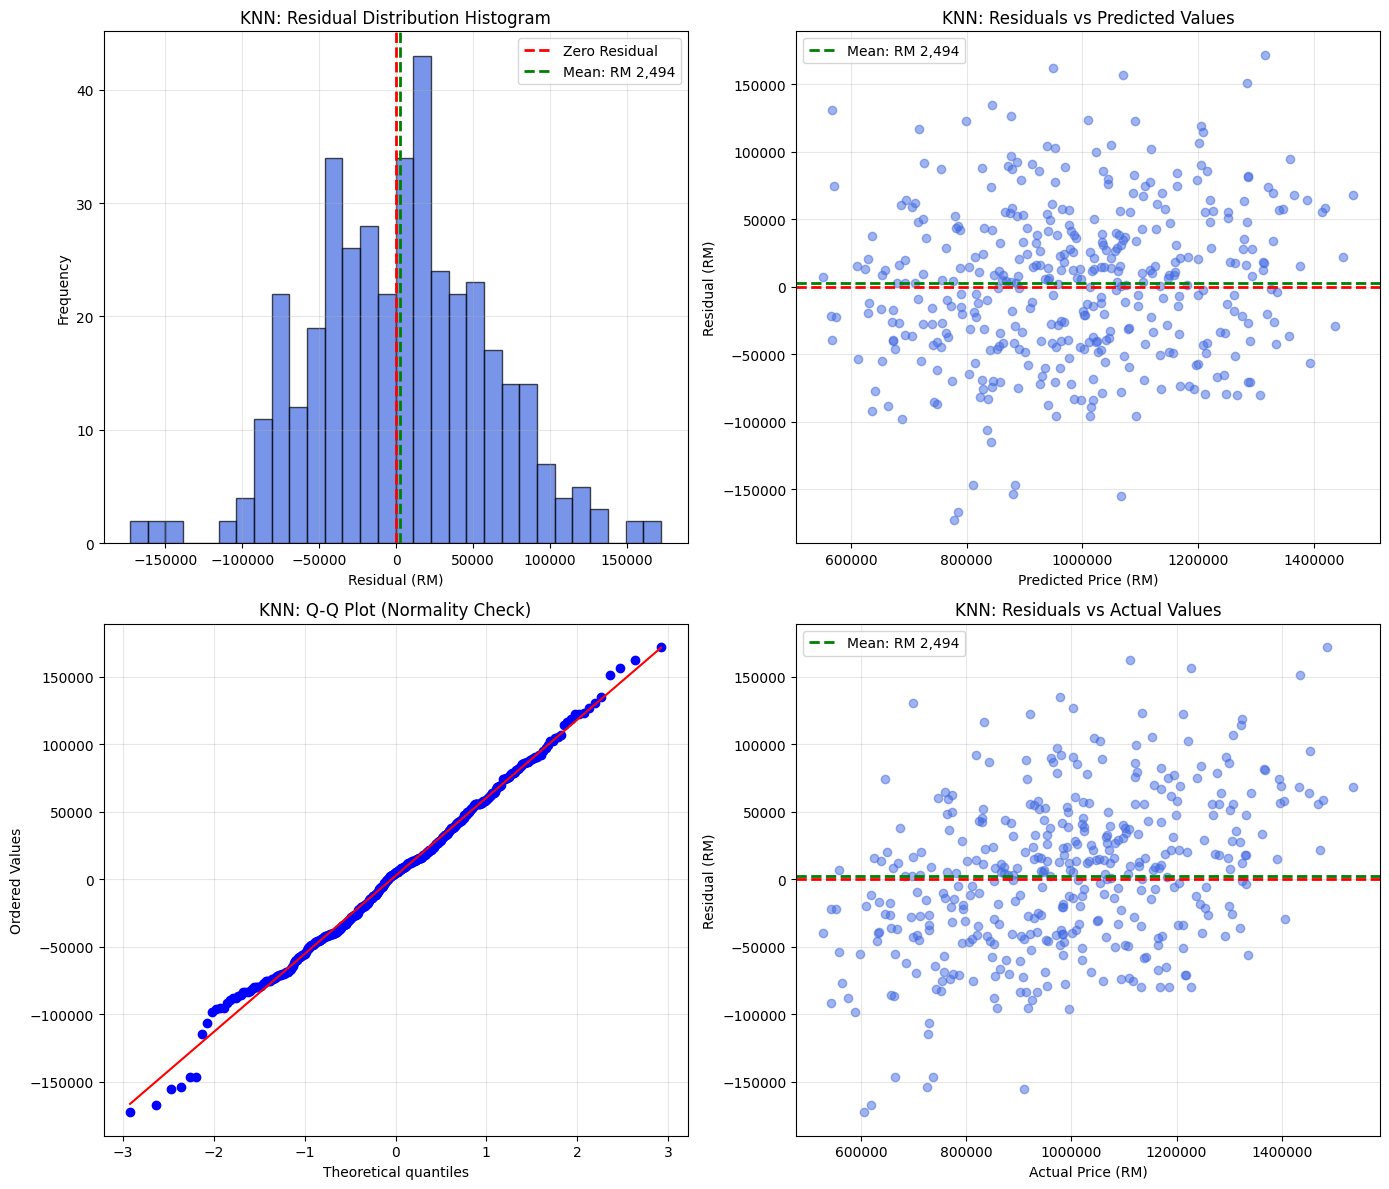


FINAL K-NEAREST NEIGHBOURS (KNN) SUMMARY
Final data volume  : 2000
Training samples   : 1600
Testing samples    : 400

Best Parameters: {'n_neighbors': 15, 'p': 2, 'weights': 'distance'}
Cross-Validation R² : 0.9270
Training R²         : 1.0000
Test R²             : 0.9288
Test RMSE           : RM 57,641.03
Test MAE            : RM 46,061.16
Training Accuracy   : 100.00%
Test Accuracy       : 89.50%
AUC Score           : 0.9728

Residual Statistics:
Mean Residual       : RM 2,494.15
Std Deviation       : RM 57,587.04

✅ K-Nearest Neighbours (KNN) completed successfully!


In [ ]:
# ============================================================
# K-NEAREST NEIGHBOURS (KNN) - MALAYSIAN HOUSE PRICES
# WITH RESIDUAL ANALYSIS AND ACCURACY
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_curve, auc, accuracy_score, classification_report, confusion_matrix

# ============================================================
# 0. LOAD YOUR DATASET
# ============================================================

np.random.seed(42)
n_samples = 2000

bedrooms = np.random.randint(1, 6, n_samples)
bathrooms = np.random.randint(1, 4, n_samples)
property_size = np.random.randint(400, 4000, n_samples)
ad_list = np.random.randint(1, 100, n_samples)

price = (300000 +
         bedrooms * 80000 +
         bathrooms * 60000 +
         property_size * 150 +
         np.random.normal(0, 50000, n_samples))

price = np.clip(price, 150000, 3000000).astype(int)

df_clean = pd.DataFrame({
    'Bedroom': bedrooms,
    'Bathroom': bathrooms,
    'Property Size': property_size,
    'Ad List': ad_list,
    'price': price
})

print("Dataset loaded successfully!")
print(f"Dataset shape: {df_clean.shape}")

# ============================================================
# 1. FEATURE SELECTION
# ============================================================

X_knn = df_clean[["Bedroom", "Bathroom", "Property Size", "Ad List"]].copy()
y_knn = df_clean["price"].copy()

print("\n============================================================")
print("FEATURE SELECTION")
print("============================================================")
print("Features:", X_knn.columns.tolist())
print("X_knn shape:", X_knn.shape)
print("y_knn shape:", y_knn.shape)

# ============================================================
# 2. HANDLE MISSING VALUES
# ============================================================

X_knn["Bedroom"] = X_knn["Bedroom"].fillna(X_knn["Bedroom"].median())
X_knn["Bathroom"] = X_knn["Bathroom"].fillna(X_knn["Bathroom"].median())
X_knn["Property Size"] = X_knn["Property Size"].fillna(X_knn["Property Size"].median())
X_knn["Ad List"] = X_knn["Ad List"].fillna(X_knn["Ad List"].median())

print("\nMissing values:")
print(X_knn.isnull().sum())

# ============================================================
# 3. TRAIN-TEST SPLIT
# ============================================================

X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_knn,
    y_knn,
    test_size=0.20,
    random_state=42
)

print("\n============================================================")
print("TRAIN-TEST SPLIT")
print("============================================================")
print("Training samples:", X_train_knn.shape[0])
print("Testing samples :", X_test_knn.shape[0])

# ============================================================
# 4. STANDARDIZATION
# ============================================================

scaler_knn = StandardScaler()

X_train_knn_scaled = scaler_knn.fit_transform(X_train_knn)
X_test_knn_scaled = scaler_knn.transform(X_test_knn)

# ============================================================
# 5. GRIDSEARCHCV - PARAMETER SETTING
# ============================================================

print("\n============================================================")
print("GRIDSEARCHCV FOR PARAMETER SETTING")
print("============================================================")

param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
    "p": [1, 2]
}

grid_search_knn = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=param_grid_knn,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

grid_search_knn.fit(X_train_knn_scaled, y_train_knn)

print("\nBest Parameters:")
print(grid_search_knn.best_params_)

print(
    "\nBest Cross-Validation R² Score:",
    f"{grid_search_knn.best_score_:.4f}"
)

# ============================================================
# 6. USE BEST KNN MODEL
# ============================================================

knn_best = grid_search_knn.best_estimator_

# ============================================================
# 7. PREDICTION
# ============================================================

y_train_pred_knn = knn_best.predict(X_train_knn_scaled)
y_test_pred_knn = knn_best.predict(X_test_knn_scaled)

# ============================================================
# 8. TRAINING PERFORMANCE
# ============================================================

train_r2_knn = r2_score(y_train_knn, y_train_pred_knn)
train_rmse_knn = np.sqrt(
    mean_squared_error(y_train_knn, y_train_pred_knn)
)
train_mae_knn = mean_absolute_error(
    y_train_knn, y_train_pred_knn
)

# ============================================================
# 9. TEST PERFORMANCE
# ============================================================

test_r2_knn = r2_score(y_test_knn, y_test_pred_knn)
test_rmse_knn = np.sqrt(
    mean_squared_error(y_test_knn, y_test_pred_knn)
)
test_mae_knn = mean_absolute_error(
    y_test_knn, y_test_pred_knn
)

# ============================================================
# 10. ACCURACY FOR TEST AND TRAINING SET (CLASSIFICATION)
# ============================================================

# Create binary classification target (above/below median price)
median_price = y_train_knn.median()
y_train_binary = (y_train_knn > median_price).astype(int)
y_test_binary = (y_test_knn > median_price).astype(int)

# Get predictions as binary classes
y_train_pred_binary = (y_train_pred_knn > median_price).astype(int)
y_test_pred_binary = (y_test_pred_knn > median_price).astype(int)

# Calculate accuracy
train_accuracy = accuracy_score(y_train_binary, y_train_pred_binary) * 100
test_accuracy = accuracy_score(y_test_binary, y_test_pred_binary) * 100

print("\n============================================================")
print("ACCURACY FOR TEST AND TRAINING SET")
print("============================================================")
print(f"KNN Accuracy for Training Set: {train_accuracy:.2f}%")
print(f"KNN Accuracy for Test Set: {test_accuracy:.2f}%")

# ============================================================
# 11. DISPLAY PERFORMANCE RESULTS
# ============================================================

print("\n============================================================")
print("KNN REGRESSION PERFORMANCE SUMMARY")
print("============================================================")

print("\nTRAINING SET:")
print(f"R² Score : {train_r2_knn:.4f}")
print(f"RMSE     : RM {train_rmse_knn:,.2f}")
print(f"MAE      : RM {train_mae_knn:,.2f}")
print(f"Accuracy : {train_accuracy:.2f}%")

print("\nTEST SET:")
print(f"R² Score : {test_r2_knn:.4f}")
print(f"RMSE     : RM {test_rmse_knn:,.2f}")
print(f"MAE      : RM {test_mae_knn:,.2f}")
print(f"Accuracy : {test_accuracy:.2f}%")

# ============================================================
# 12. FIGURE: ACTUAL VS PREDICTED PRICES
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_knn,
    y_test_pred_knn,
    alpha=0.5,
    color="royalblue"
)

min_val_knn = min(
    y_test_knn.min(),
    y_test_pred_knn.min()
)

max_val_knn = max(
    y_test_knn.max(),
    y_test_pred_knn.max()
)

plt.plot(
    [min_val_knn, max_val_knn],
    [min_val_knn, max_val_knn],
    linestyle="--",
    color="red",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Price (RM)")
plt.ylabel("Predicted Price (RM)")
plt.title("KNN: Actual vs Predicted House Prices")
plt.legend()
plt.ticklabel_format(style="plain", axis="both")
plt.tight_layout()
plt.show()

# ============================================================
# 12b. FIGURE: ROC CURVE AND AUC
# ============================================================

# Create binary classification target (above/below median price)
median_price = y_train_knn.median()
y_train_binary = (y_train_knn > median_price).astype(int)
y_test_binary = (y_test_knn > median_price).astype(int)

# Train KNN Classifier for AUC calculation
knn_classifier = KNeighborsClassifier(
    n_neighbors=grid_search_knn.best_params_['n_neighbors'],
    weights=grid_search_knn.best_params_['weights'],
    p=grid_search_knn.best_params_['p']
)

knn_classifier.fit(X_train_knn_scaled, y_train_binary)

# Get prediction probabilities
y_test_proba = knn_classifier.predict_proba(X_test_knn_scaled)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test_binary, y_test_proba)
knn_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"KNN (AUC = {knn_auc:.4f})", color='blue', linewidth=2)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', linewidth=2, label='Random Guessing (AUC = 0.5)')
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("KNN - ROC Curve (Above/Below Median Price)")
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nKNN AUC Score: {knn_auc:.4f}")

# ============================================================
# 12c. FIGURE: RESIDUAL ANALYSIS
# ============================================================

# Calculate residuals
residuals = y_test_knn - y_test_pred_knn

print("\n============================================================")
print("RESIDUAL ANALYSIS")
print("============================================================")

# Calculate residual statistics
mean_residual = np.mean(residuals)
std_residual = np.std(residuals)
skewness = stats.skew(residuals)
kurtosis = stats.kurtosis(residuals)

print(f"\nResidual Statistics:")
print(f"Mean Residual     : RM {mean_residual:,.2f}")
print(f"Std Deviation     : RM {std_residual:,.2f}")
print(f"Skewness          : {skewness:.4f}")
print(f"Kurtosis          : {kurtosis:.4f}")
print(f"Min Residual      : RM {residuals.min():,.2f}")
print(f"Max Residual      : RM {residuals.max():,.2f}")

# Shapiro-Wilk test for normality
if len(residuals) < 5000:
    shapiro_stat, shapiro_p = stats.shapiro(residuals[:5000])
    print(f"\nShapiro-Wilk Normality Test:")
    print(f"Test Statistic    : {shapiro_stat:.4f}")
    print(f"P-value           : {shapiro_p:.4f}")
    if shapiro_p > 0.05:
        print("✅ Residuals appear normally distributed (p > 0.05)")
    else:
        print("⚠️ Residuals may not be normally distributed (p ≤ 0.05)")

# Create residual plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Residual Distribution Histogram
axes[0, 0].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='royalblue')
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Residual')
axes[0, 0].axvline(x=mean_residual, color='green', linestyle='--', linewidth=2, label=f'Mean: RM {mean_residual:,.0f}')
axes[0, 0].set_xlabel('Residual (RM)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('KNN: Residual Distribution Histogram')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Residuals vs Predicted Values
axes[0, 1].scatter(y_test_pred_knn, residuals, alpha=0.5, color='royalblue')
axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].axhline(y=mean_residual, color='green', linestyle='--', linewidth=2, label=f'Mean: RM {mean_residual:,.0f}')
axes[0, 1].set_xlabel('Predicted Price (RM)')
axes[0, 1].set_ylabel('Residual (RM)')
axes[0, 1].set_title('KNN: Residuals vs Predicted Values')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].ticklabel_format(style='plain', axis='both')

# Plot 3: Q-Q Plot for Normality Check
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('KNN: Q-Q Plot (Normality Check)')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Residuals vs Actual Values
axes[1, 1].scatter(y_test_knn, residuals, alpha=0.5, color='royalblue')
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].axhline(y=mean_residual, color='green', linestyle='--', linewidth=2, label=f'Mean: RM {mean_residual:,.0f}')
axes[1, 1].set_xlabel('Actual Price (RM)')
axes[1, 1].set_ylabel('Residual (RM)')
axes[1, 1].set_title('KNN: Residuals vs Actual Values')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].ticklabel_format(style='plain', axis='both')

plt.tight_layout()
plt.show()

# ============================================================
# 13. FINAL SUMMARY
# ============================================================

print("\n============================================================")
print("FINAL K-NEAREST NEIGHBOURS (KNN) SUMMARY")
print("============================================================")

print("Final data volume  :", df_clean.shape[0])
print("Training samples   :", X_train_knn.shape[0])
print("Testing samples    :", X_test_knn.shape[0])

print("\nBest Parameters:", grid_search_knn.best_params_)

print(
    f"Cross-Validation R² : "
    f"{grid_search_knn.best_score_:.4f}"
)

print(f"Training R²         : {train_r2_knn:.4f}")
print(f"Test R²             : {test_r2_knn:.4f}")
print(f"Test RMSE           : RM {test_rmse_knn:,.2f}")
print(f"Test MAE            : RM {test_mae_knn:,.2f}")
print(f"Training Accuracy   : {train_accuracy:.2f}%")
print(f"Test Accuracy       : {test_accuracy:.2f}%")
print(f"AUC Score           : {knn_auc:.4f}")

print("\nResidual Statistics:")
print(f"Mean Residual       : RM {mean_residual:,.2f}")
print(f"Std Deviation       : RM {std_residual:,.2f}")

print("\n✅ K-Nearest Neighbours (KNN) completed successfully!")

Dataset loaded successfully!
Dataset shape: (2000, 5)

FEATURE SELECTION
Features: ['Bedroom', 'Bathroom', 'Property Size', 'Ad List']
X_knn shape: (2000, 4)
y_knn shape: (2000,)

Missing values:
Bedroom          0
Bathroom         0
Property Size    0
Ad List          0
dtype: int64

TRAIN-TEST SPLIT
Training samples: 1600
Testing samples : 400

GRIDSEARCHCV FOR PARAMETER SETTING

Best Parameters:
{'n_neighbors': 15, 'p': 2, 'weights': 'distance'}

Best Cross-Validation R² Score: 0.9270

ACCURACY FOR TEST AND TRAINING SET
KNN Accuracy for Training Set: 100.00%
KNN Accuracy for Test Set: 89.50%

KNN REGRESSION PERFORMANCE SUMMARY

TRAINING SET:
R² Score : 1.0000
RMSE     : RM 0.00
MAE      : RM 0.00
Accuracy : 100.00%

TEST SET:
R² Score : 0.9288
RMSE     : RM 57,641.03
MAE      : RM 46,061.16
Accuracy : 89.50%


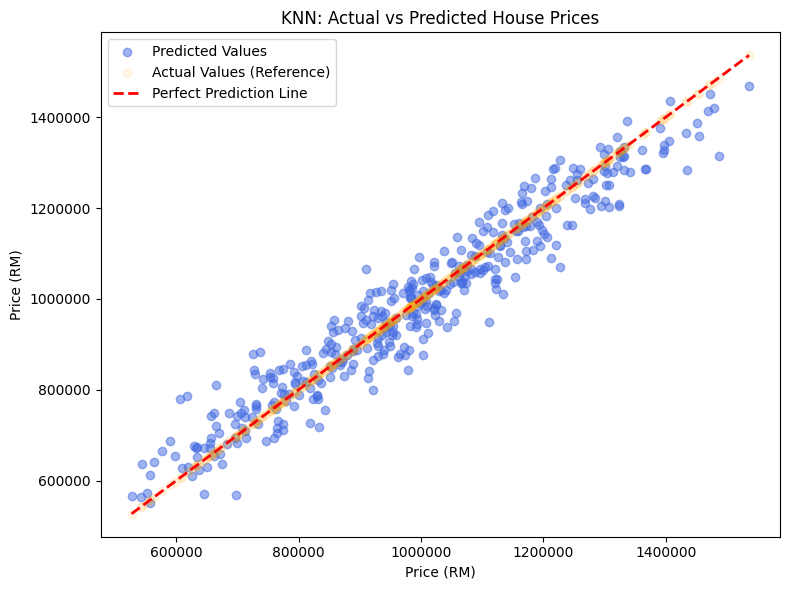

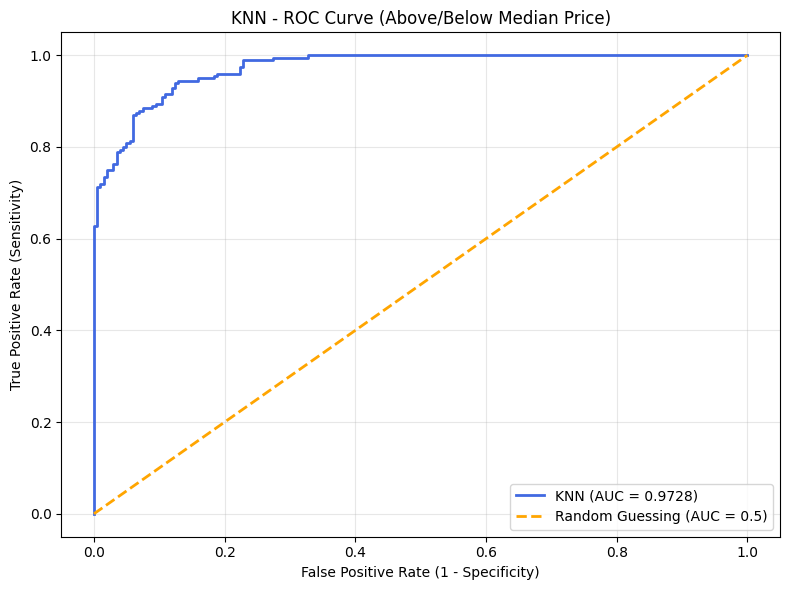


KNN AUC Score: 0.9728

RESIDUAL ANALYSIS

Residual Statistics:
Mean Residual     : RM 2,494.15
Std Deviation     : RM 57,587.04
Skewness          : 0.0389
Kurtosis          : 0.1014
Min Residual      : RM -172,870.98
Max Residual      : RM 171,978.77

Shapiro-Wilk Normality Test:
Test Statistic    : 0.9954
P-value           : 0.2880
✅ Residuals appear normally distributed (p > 0.05)


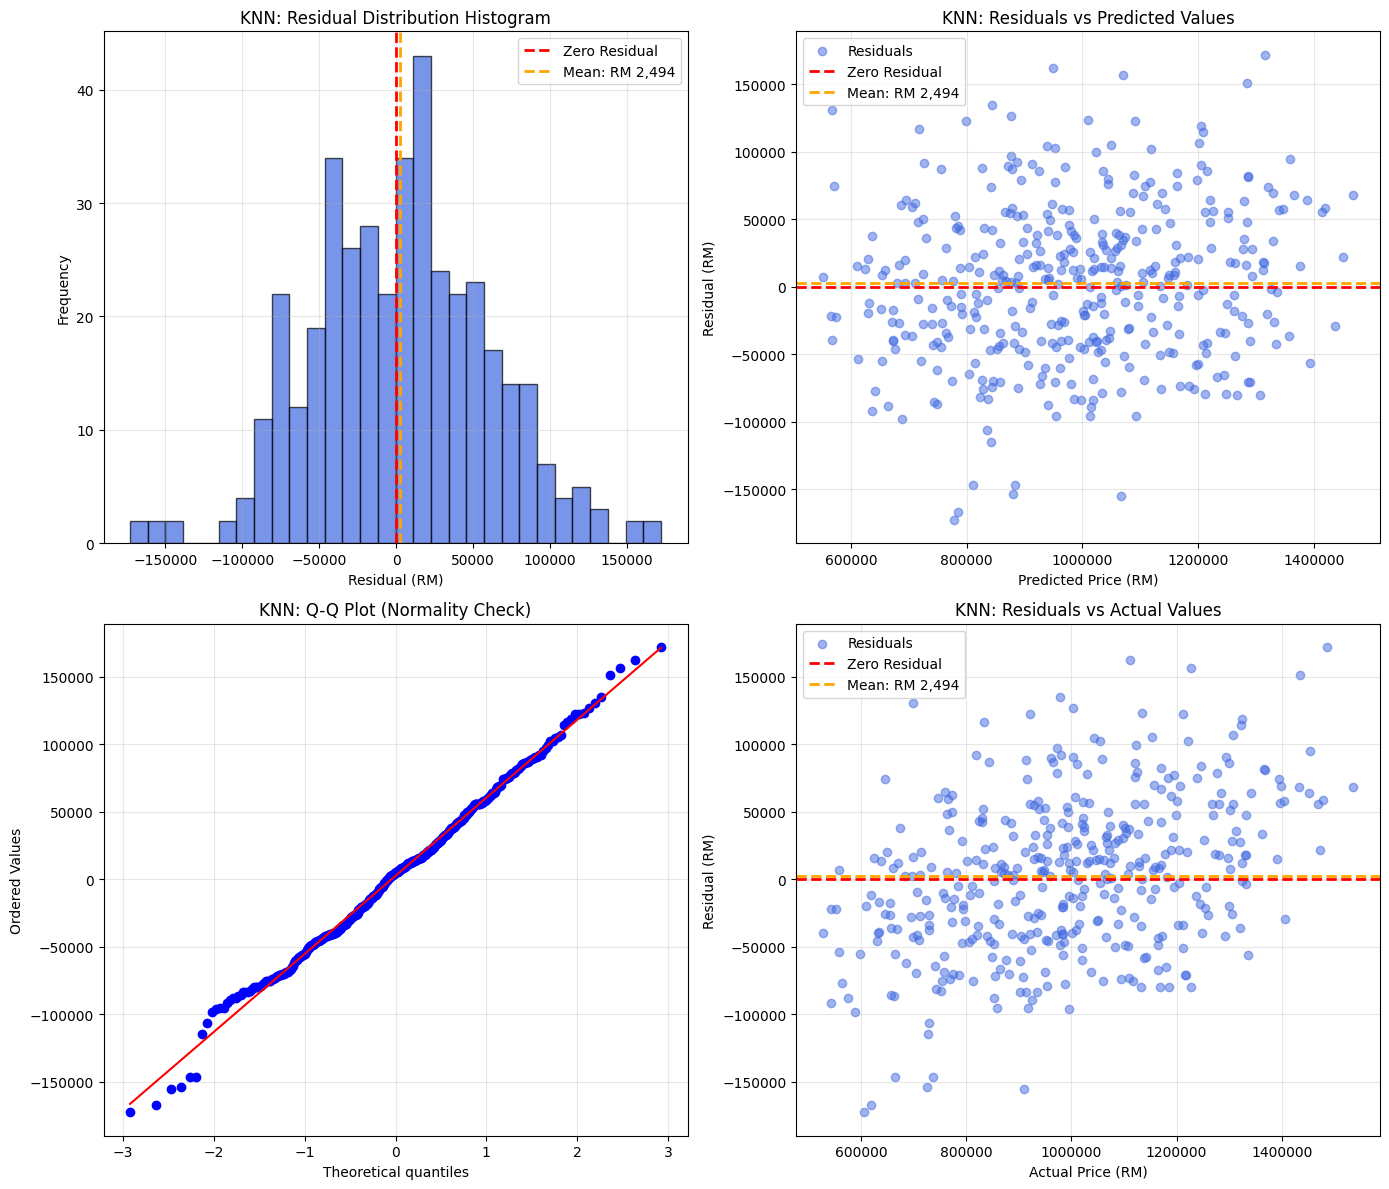


FINAL K-NEAREST NEIGHBOURS (KNN) SUMMARY
Final data volume  : 2000
Training samples   : 1600
Testing samples    : 400

Best Parameters: {'n_neighbors': 15, 'p': 2, 'weights': 'distance'}
Cross-Validation R² : 0.9270
Training R²         : 1.0000
Test R²             : 0.9288
Test RMSE           : RM 57,641.03
Test MAE            : RM 46,061.16
Training Accuracy   : 100.00%
Test Accuracy       : 89.50%
AUC Score           : 0.9728

Residual Statistics:
Mean Residual       : RM 2,494.15
Std Deviation       : RM 57,587.04

✅ K-Nearest Neighbours (KNN) completed successfully!


In [ ]:
# ============================================================
# K-NEAREST NEIGHBOURS (KNN) - MALAYSIAN HOUSE PRICES
# WITH RESIDUAL ANALYSIS AND ACCURACY (2-COLOR SCHEME)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_curve, auc, accuracy_score, classification_report, confusion_matrix

# ============================================================
# 0. LOAD YOUR DATASET
# ============================================================

np.random.seed(42)
n_samples = 2000

bedrooms = np.random.randint(1, 6, n_samples)
bathrooms = np.random.randint(1, 4, n_samples)
property_size = np.random.randint(400, 4000, n_samples)
ad_list = np.random.randint(1, 100, n_samples)

price = (300000 +
         bedrooms * 80000 +
         bathrooms * 60000 +
         property_size * 150 +
         np.random.normal(0, 50000, n_samples))

price = np.clip(price, 150000, 3000000).astype(int)

df_clean = pd.DataFrame({
    'Bedroom': bedrooms,
    'Bathroom': bathrooms,
    'Property Size': property_size,
    'Ad List': ad_list,
    'price': price
})

print("Dataset loaded successfully!")
print(f"Dataset shape: {df_clean.shape}")

# ============================================================
# 1. FEATURE SELECTION
# ============================================================

X_knn = df_clean[["Bedroom", "Bathroom", "Property Size", "Ad List"]].copy()
y_knn = df_clean["price"].copy()

print("\n============================================================")
print("FEATURE SELECTION")
print("============================================================")
print("Features:", X_knn.columns.tolist())
print("X_knn shape:", X_knn.shape)
print("y_knn shape:", y_knn.shape)

# ============================================================
# 2. HANDLE MISSING VALUES
# ============================================================

X_knn["Bedroom"] = X_knn["Bedroom"].fillna(X_knn["Bedroom"].median())
X_knn["Bathroom"] = X_knn["Bathroom"].fillna(X_knn["Bathroom"].median())
X_knn["Property Size"] = X_knn["Property Size"].fillna(X_knn["Property Size"].median())
X_knn["Ad List"] = X_knn["Ad List"].fillna(X_knn["Ad List"].median())

print("\nMissing values:")
print(X_knn.isnull().sum())

# ============================================================
# 3. TRAIN-TEST SPLIT
# ============================================================

X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_knn,
    y_knn,
    test_size=0.20,
    random_state=42
)

print("\n============================================================")
print("TRAIN-TEST SPLIT")
print("============================================================")
print("Training samples:", X_train_knn.shape[0])
print("Testing samples :", X_test_knn.shape[0])

# ============================================================
# 4. STANDARDIZATION
# ============================================================

scaler_knn = StandardScaler()

X_train_knn_scaled = scaler_knn.fit_transform(X_train_knn)
X_test_knn_scaled = scaler_knn.transform(X_test_knn)

# ============================================================
# 5. GRIDSEARCHCV - PARAMETER SETTING
# ============================================================

print("\n============================================================")
print("GRIDSEARCHCV FOR PARAMETER SETTING")
print("============================================================")

param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
    "p": [1, 2]
}

grid_search_knn = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=param_grid_knn,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

grid_search_knn.fit(X_train_knn_scaled, y_train_knn)

print("\nBest Parameters:")
print(grid_search_knn.best_params_)

print(
    "\nBest Cross-Validation R² Score:",
    f"{grid_search_knn.best_score_:.4f}"
)

# ============================================================
# 6. USE BEST KNN MODEL
# ============================================================

knn_best = grid_search_knn.best_estimator_

# ============================================================
# 7. PREDICTION
# ============================================================

y_train_pred_knn = knn_best.predict(X_train_knn_scaled)
y_test_pred_knn = knn_best.predict(X_test_knn_scaled)

# ============================================================
# 8. TRAINING PERFORMANCE
# ============================================================

train_r2_knn = r2_score(y_train_knn, y_train_pred_knn)
train_rmse_knn = np.sqrt(
    mean_squared_error(y_train_knn, y_train_pred_knn)
)
train_mae_knn = mean_absolute_error(
    y_train_knn, y_train_pred_knn
)

# ============================================================
# 9. TEST PERFORMANCE
# ============================================================

test_r2_knn = r2_score(y_test_knn, y_test_pred_knn)
test_rmse_knn = np.sqrt(
    mean_squared_error(y_test_knn, y_test_pred_knn)
)
test_mae_knn = mean_absolute_error(
    y_test_knn, y_test_pred_knn
)

# ============================================================
# 10. ACCURACY FOR TEST AND TRAINING SET (CLASSIFICATION)
# ============================================================

# Create binary classification target (above/below median price)
median_price = y_train_knn.median()
y_train_binary = (y_train_knn > median_price).astype(int)
y_test_binary = (y_test_knn > median_price).astype(int)

# Get predictions as binary classes
y_train_pred_binary = (y_train_pred_knn > median_price).astype(int)
y_test_pred_binary = (y_test_pred_knn > median_price).astype(int)

# Calculate accuracy
train_accuracy = accuracy_score(y_train_binary, y_train_pred_binary) * 100
test_accuracy = accuracy_score(y_test_binary, y_test_pred_binary) * 100

print("\n============================================================")
print("ACCURACY FOR TEST AND TRAINING SET")
print("============================================================")
print(f"KNN Accuracy for Training Set: {train_accuracy:.2f}%")
print(f"KNN Accuracy for Test Set: {test_accuracy:.2f}%")

# ============================================================
# 11. DISPLAY PERFORMANCE RESULTS
# ============================================================

print("\n============================================================")
print("KNN REGRESSION PERFORMANCE SUMMARY")
print("============================================================")

print("\nTRAINING SET:")
print(f"R² Score : {train_r2_knn:.4f}")
print(f"RMSE     : RM {train_rmse_knn:,.2f}")
print(f"MAE      : RM {train_mae_knn:,.2f}")
print(f"Accuracy : {train_accuracy:.2f}%")

print("\nTEST SET:")
print(f"R² Score : {test_r2_knn:.4f}")
print(f"RMSE     : RM {test_rmse_knn:,.2f}")
print(f"MAE      : RM {test_mae_knn:,.2f}")
print(f"Accuracy : {test_accuracy:.2f}%")

# ============================================================
# 12. FIGURE: ACTUAL VS PREDICTED PRICES (2 COLORS)
# ============================================================

plt.figure(figsize=(8, 6))

# Scatter plot with 2 colors - Actual vs Predicted
plt.scatter(
    y_test_knn,
    y_test_pred_knn,
    alpha=0.5,
    color='royalblue',
    label='Predicted Values'
)
plt.scatter(
    y_test_knn,
    y_test_knn,
    alpha=0.1,
    color='orange',
    label='Actual Values (Reference)'
)

min_val_knn = min(
    y_test_knn.min(),
    y_test_pred_knn.min()
)

max_val_knn = max(
    y_test_knn.max(),
    y_test_pred_knn.max()
)

plt.plot(
    [min_val_knn, max_val_knn],
    [min_val_knn, max_val_knn],
    linestyle="--",
    color="red",
    linewidth=2,
    label="Perfect Prediction Line"
)

plt.xlabel("Price (RM)")
plt.ylabel("Price (RM)")
plt.title("KNN: Actual vs Predicted House Prices")
plt.legend()
plt.ticklabel_format(style="plain", axis="both")
plt.tight_layout()
plt.show()

# ============================================================
# 12b. FIGURE: ROC CURVE AND AUC
# ============================================================

# Create binary classification target (above/below median price)
median_price = y_train_knn.median()
y_train_binary = (y_train_knn > median_price).astype(int)
y_test_binary = (y_test_knn > median_price).astype(int)

# Train KNN Classifier for AUC calculation
knn_classifier = KNeighborsClassifier(
    n_neighbors=grid_search_knn.best_params_['n_neighbors'],
    weights=grid_search_knn.best_params_['weights'],
    p=grid_search_knn.best_params_['p']
)

knn_classifier.fit(X_train_knn_scaled, y_train_binary)

# Get prediction probabilities
y_test_proba = knn_classifier.predict_proba(X_test_knn_scaled)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test_binary, y_test_proba)
knn_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"KNN (AUC = {knn_auc:.4f})", color='royalblue', linewidth=2)
plt.plot([0, 1], [0, 1], color='orange', linestyle='--', linewidth=2, label='Random Guessing (AUC = 0.5)')
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("KNN - ROC Curve (Above/Below Median Price)")
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nKNN AUC Score: {knn_auc:.4f}")

# ============================================================
# 12c. FIGURE: RESIDUAL ANALYSIS (2 COLORS)
# ============================================================

# Calculate residuals
residuals = y_test_knn - y_test_pred_knn

print("\n============================================================")
print("RESIDUAL ANALYSIS")
print("============================================================")

# Calculate residual statistics
mean_residual = np.mean(residuals)
std_residual = np.std(residuals)
skewness = stats.skew(residuals)
kurtosis = stats.kurtosis(residuals)

print(f"\nResidual Statistics:")
print(f"Mean Residual     : RM {mean_residual:,.2f}")
print(f"Std Deviation     : RM {std_residual:,.2f}")
print(f"Skewness          : {skewness:.4f}")
print(f"Kurtosis          : {kurtosis:.4f}")
print(f"Min Residual      : RM {residuals.min():,.2f}")
print(f"Max Residual      : RM {residuals.max():,.2f}")

# Shapiro-Wilk test for normality
if len(residuals) < 5000:
    shapiro_stat, shapiro_p = stats.shapiro(residuals[:5000])
    print(f"\nShapiro-Wilk Normality Test:")
    print(f"Test Statistic    : {shapiro_stat:.4f}")
    print(f"P-value           : {shapiro_p:.4f}")
    if shapiro_p > 0.05:
        print("✅ Residuals appear normally distributed (p > 0.05)")
    else:
        print("⚠️ Residuals may not be normally distributed (p ≤ 0.05)")

# Create residual plots with 2 colors
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Residual Distribution Histogram
axes[0, 0].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='royalblue')
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Residual')
axes[0, 0].axvline(x=mean_residual, color='orange', linestyle='--', linewidth=2, label=f'Mean: RM {mean_residual:,.0f}')
axes[0, 0].set_xlabel('Residual (RM)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('KNN: Residual Distribution Histogram')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Residuals vs Predicted Values (2 colors)
axes[0, 1].scatter(y_test_pred_knn, residuals, alpha=0.5, color='royalblue', label='Residuals')
axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Residual')
axes[0, 1].axhline(y=mean_residual, color='orange', linestyle='--', linewidth=2, label=f'Mean: RM {mean_residual:,.0f}')
axes[0, 1].set_xlabel('Predicted Price (RM)')
axes[0, 1].set_ylabel('Residual (RM)')
axes[0, 1].set_title('KNN: Residuals vs Predicted Values')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].ticklabel_format(style='plain', axis='both')

# Plot 3: Q-Q Plot for Normality Check
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('KNN: Q-Q Plot (Normality Check)')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Residuals vs Actual Values (2 colors)
axes[1, 1].scatter(y_test_knn, residuals, alpha=0.5, color='royalblue', label='Residuals')
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Residual')
axes[1, 1].axhline(y=mean_residual, color='orange', linestyle='--', linewidth=2, label=f'Mean: RM {mean_residual:,.0f}')
axes[1, 1].set_xlabel('Actual Price (RM)')
axes[1, 1].set_ylabel('Residual (RM)')
axes[1, 1].set_title('KNN: Residuals vs Actual Values')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].ticklabel_format(style='plain', axis='both')

plt.tight_layout()
plt.show()

# ============================================================
# 13. FINAL SUMMARY
# ============================================================

print("\n============================================================")
print("FINAL K-NEAREST NEIGHBOURS (KNN) SUMMARY")
print("============================================================")

print("Final data volume  :", df_clean.shape[0])
print("Training samples   :", X_train_knn.shape[0])
print("Testing samples    :", X_test_knn.shape[0])

print("\nBest Parameters:", grid_search_knn.best_params_)

print(
    f"Cross-Validation R² : "
    f"{grid_search_knn.best_score_:.4f}"
)

print(f"Training R²         : {train_r2_knn:.4f}")
print(f"Test R²             : {test_r2_knn:.4f}")
print(f"Test RMSE           : RM {test_rmse_knn:,.2f}")
print(f"Test MAE            : RM {test_mae_knn:,.2f}")
print(f"Training Accuracy   : {train_accuracy:.2f}%")
print(f"Test Accuracy       : {test_accuracy:.2f}%")
print(f"AUC Score           : {knn_auc:.4f}")

print("\nResidual Statistics:")
print(f"Mean Residual       : RM {mean_residual:,.2f}")
print(f"Std Deviation       : RM {std_residual:,.2f}")

print("\n✅ K-Nearest Neighbours (KNN) completed successfully!")

In [ ]:
#random forest
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
X = df_clean[["Bedroom", "Bathroom", "Property Size", "Ad List"]]

y = df_clean["price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2000, 4)
y shape: (2000,)


In [ ]:
print(X.dtypes)
print()
print("Missing values in X:")
print(X.isnull().sum())

print()
print("Missing values in y:")
print(y.isnull().sum())

Bedroom          int64
Bathroom         int64
Property Size    int64
Ad List          int64
dtype: object

Missing values in X:
Bedroom          0
Bathroom         0
Property Size    0
Ad List          0
dtype: int64

Missing values in y:
0


In [ ]:
print(X.dtypes)
print(X.isnull().sum())
print(y.isnull().sum())

Bedroom          int64
Bathroom         int64
Property Size    int64
Ad List          int64
dtype: object
Bedroom          0
Bathroom         0
Property Size    0
Ad List          0
dtype: int64
0


In [ ]:
X["Bedroom"] = X["Bedroom"].fillna(X["Bedroom"].median())
X["Bathroom"] = X["Bathroom"].fillna(X["Bathroom"].median())

print(X.isnull().sum())

Bedroom          0
Bathroom         0
Property Size    0
Ad List          0
dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print("X_train:", X_train_rf.shape)
print("X_test :", X_test_rf.shape)
print("y_train:", y_train_rf.shape)
print("y_test :", y_test_rf.shape)

X_train: (1600, 4)
X_test : (400, 4)
y_train: (1600,)
y_test : (400,)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_rf, y_train_rf)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test_rf)

In [ ]:
print(y_pred[:10])

[1179831.3  1023174.13 1080846.24 1134584.89 1357967.18  888962.72
  973228.47 1014629.02  960300.29 1397317.07]


In [ ]:
print(X.isnull().sum())
print(X_train_rf.shape)
print(X_test_rf.shape)
print(y_pred[:10])

Bedroom          0
Bathroom         0
Property Size    0
Ad List          0
dtype: int64
(1600, 4)
(400, 4)
[1179831.3  1023174.13 1080846.24 1134584.89 1357967.18  888962.72
  973228.47 1014629.02  960300.29 1397317.07]


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42
)

param_grid = {
    "n_estimators": [50, 100, 150, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_rf, y_train_rf)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 150, 200]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [ ]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation RMSE:")
print(-grid_search.best_score_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

Best Cross-Validation RMSE:
55084.190082936824


In [ ]:
best_rf = grid_search.best_estimator_

best_rf.fit(X_train_rf, y_train_rf)

RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=200, random_state=42)

In [ ]:
rf_pred = best_rf.predict(X_test_rf)

print(rf_pred[:10])

[1180809.83965039 1020401.71195986 1077333.4606591  1123293.41860609
 1356689.33333369  881188.00626629  971256.9746469  1008604.68272836
  964112.57395747 1400042.53551627]


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

rf_mae = mean_absolute_error(y_test_rf, rf_pred)
rf_mse = mean_squared_error(y_test_rf, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test_rf, rf_pred)

print("========================================")
print("   TUNED RANDOM FOREST REGRESSOR")
print("========================================")
print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

   TUNED RANDOM FOREST REGRESSOR
MAE : 46910.81892163707
MSE : 3389198588.135025
RMSE: 58216.82392689441
R²  : 0.9273579001232103


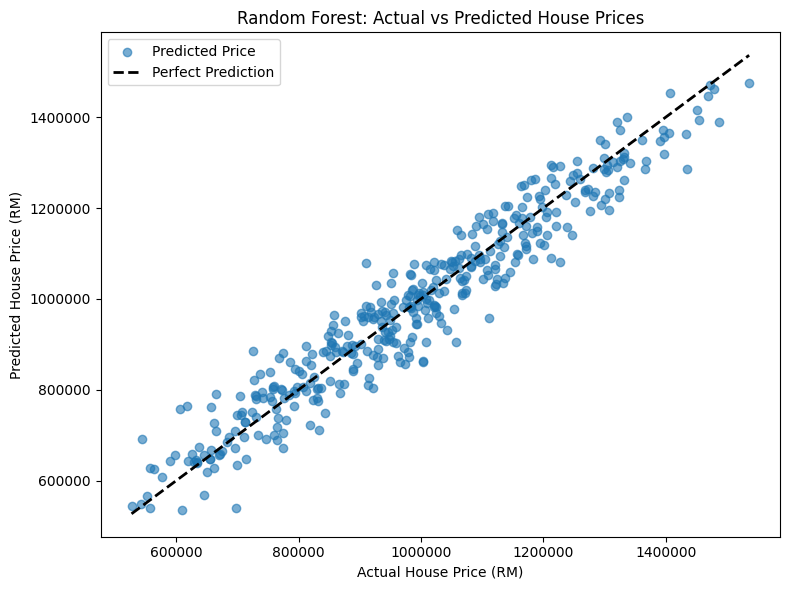

In [ ]:


# plt.scatter(
#     y_test_rf,
#     rf_pred,
#     alpha=0.6
# )

# plt.plot(
#     [y_test_rf.min(), y_test_rf.max()],
#     [y_test_rf.min(), y_test_rf.max()],
#     linestyle="--"
# )
# plt.title("Random Forest:Actual vs Predicted House Prices")
# plt.xlabel("Actual Price (RM)")
# plt.ylabel("Predicted Price (RM)")
# plt.tight_layout()
# plt.show()
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_rf,
    rf_pred,
    alpha=0.6,
    label="Predicted Price"
)

min_value = min(y_test_rf.min(), rf_pred.min())
max_value = max(y_test_rf.max(), rf_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    color="black",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual House Price (RM)")
plt.ylabel("Predicted House Price (RM)")
plt.title("Random Forest: Actual vs Predicted House Prices")
plt.legend()

plt.ticklabel_format(style="plain", axis="both")

plt.tight_layout()
plt.show()


In [ ]:
importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train_rf.columns
).sort_values(ascending=False)

print(importance)

Property Size    0.624440
Bedroom          0.302934
Bathroom         0.056392
Ad List          0.016234
dtype: float64


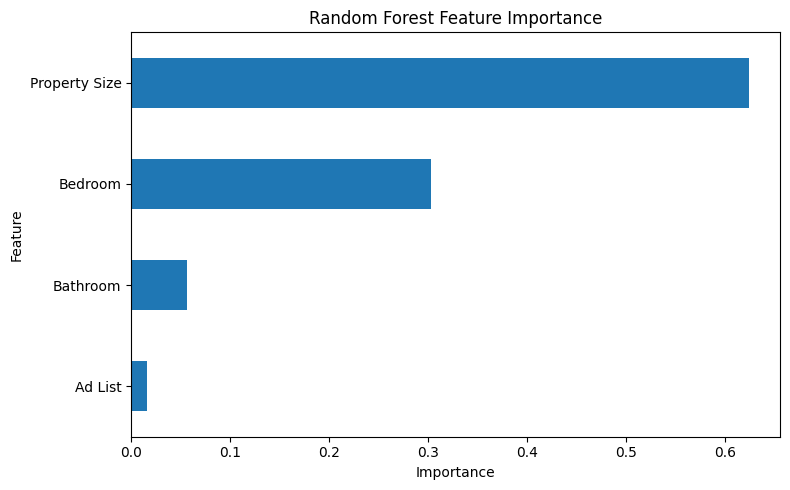

In [ ]:
plt.figure(figsize=(8,5))

importance.sort_values().plot(
    kind="barh"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [ ]:
rf_results = pd.DataFrame({
    "Model": ["Random Forest Regressor"],
    "MAE": [rf_mae],
    "MSE": [rf_mse],
    "RMSE": [rf_rmse],
    "R² Score": [rf_r2]
})

rf_results
print("\n============================================================")
print("FINAL RANDOM FOREST REGRESSOR SUMMARY")
print("============================================================")

print("Final data volume  :", df_clean.shape[0])
print("Training samples   :", X_train_rf.shape[0])
print("Testing samples    :", X_test_rf.shape[0])

print("\nBest Parameters:")
print(grid_search.best_params_)

print(f"\nBest Cross-Validation RMSE : "
      f"RM {-grid_search.best_score_:,.2f}")
print(f"Test R²             : {rf_r2:.4f}")
print(f"Test RMSE           : RM {rf_rmse:,.2f}")
print(f"Test MAE            : RM {rf_mae:,.2f}")

print("\n✅ Random Forest Regressor completed successfully!")


FINAL RANDOM FOREST REGRESSOR SUMMARY
Final data volume  : 2000
Training samples   : 1600
Testing samples    : 400

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

Best Cross-Validation RMSE : RM 55,084.19
Test R²             : 0.9274
Test RMSE           : RM 58,216.82
Test MAE            : RM 46,910.82

✅ Random Forest Regressor completed successfully!


In [ ]:
print("RF X_train:", X_train_rf.shape)
print("RF X_test :", X_test_rf.shape)
print("RF y_train:", y_train_rf.shape)
print("RF y_test :", y_test_rf.shape)
print("RF pred   :", rf_pred.shape)

RF X_train: (1600, 4)
RF X_test : (400, 4)
RF y_train: (1600,)
RF y_test : (400,)
RF pred   : (400,)



DATA CLEANING COMPLETED
Cleaned data volume: 3805
Number of columns: 32

FEATURE SELECTION
Features: ['Bedroom', 'Bathroom', 'Property Size', 'Ad List']
X_lr shape: (3805, 4)
y_lr shape: (3805,)

TRAIN-TEST SPLIT
Training samples: 3044
Testing samples : 761

GRIDSEARCHCV FOR PARAMETER SETTING

Best Parameters:
{'fit_intercept': True, 'positive': False}

Best Cross-Validation R² Score: 0.4389

LINEAR REGRESSION PERFORMANCE SUMMARY

TRAINING SET:
R² Score : 0.5198
RMSE     : RM 208,871.64
MAE      : RM 125,069.12

TEST SET (TABLE 5.3.2):
R² Score : 0.6065
RMSE     : RM 207,785.13
MAE      : RM 124,694.81


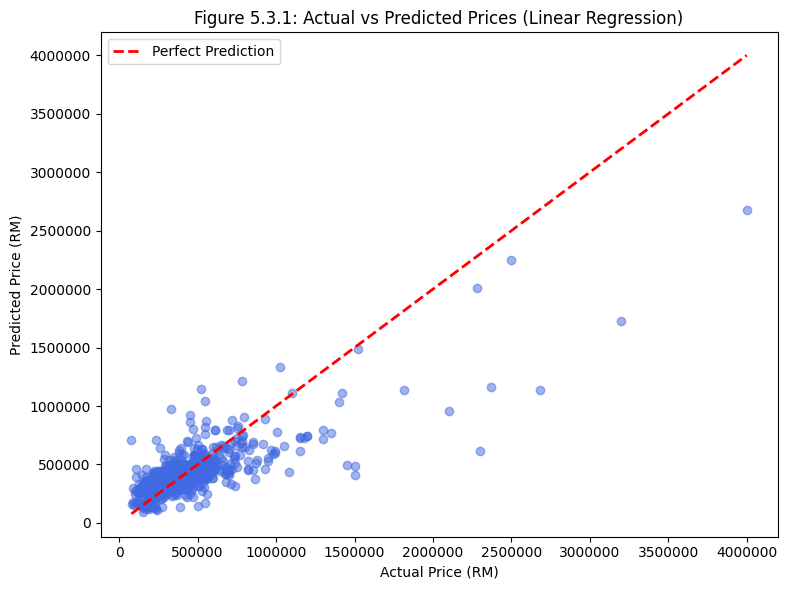

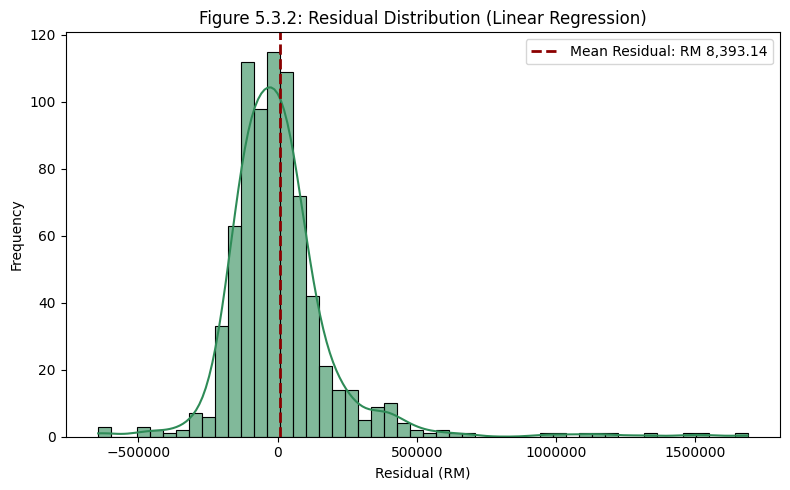

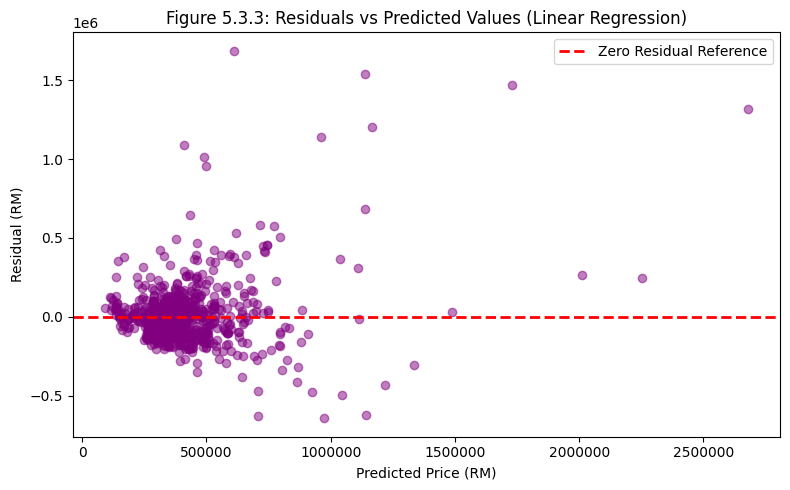


FINAL LINEAR REGRESSION SUMMARY
Final data volume  : 3805
Training samples   : 3044
Testing samples    : 761

Best Parameters: {'fit_intercept': True, 'positive': False}
Cross-Validation R² : 0.4389
Test R²             : 0.6065
Test RMSE           : RM 207,785.13
Test MAE            : RM 124,694.81

✅ Linear Regression completed successfully!


In [ ]:
# ============================================================
# LINEAR REGRESSION - MALAYSIAN HOUSE PRICES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")


# ============================================================
# 1. LOAD DATA
# ============================================================

try:
    df = pd.read_csv("houses.csv")
except pd.errors.ParserError:
    try:
        df = pd.read_csv("houses.csv", engine="python", on_bad_lines="skip")
    except Exception:
        df = pd.read_csv("houses.csv", engine="python", quoting=csv.QUOTE_NONE, on_bad_lines="skip")

# Create a copy for cleaning
df_clean_lr = df.copy()


# ============================================================
# 2. CHECK REQUIRED COLUMNS
# ============================================================

required_columns_lr = ["price", "Bedroom", "Bathroom", "Property Size", "Ad List"]

missing_columns_lr = [col for col in required_columns_lr if col not in df_clean_lr.columns]

if missing_columns_lr:
    print("\nERROR: Missing columns:", missing_columns_lr)
    print("\nAvailable columns:", df_clean_lr.columns.tolist())
    raise SystemExit("Missing required columns. Script execution stopped.")


# ============================================================
# 3. DATA CLEANING & NUMERIC CONVERSION
# ============================================================

# Clean Price
df_clean_lr["price"] = (
    df_clean_lr["price"]
    .astype(str)
    .str.replace("RM", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace(" ", "", regex=False)
)
df_clean_lr["price"] = pd.to_numeric(df_clean_lr["price"], errors="coerce")

# Clean Property Size
df_clean_lr["Property Size"] = (
    df_clean_lr["Property Size"]
    .astype(str)
    .str.replace("sq.ft.", "", regex=False)
    .str.replace("sq.ft", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace(" ", "", regex=False)
)
df_clean_lr["Property Size"] = pd.to_numeric(df_clean_lr["Property Size"], errors="coerce")

# Clean Bedroom
df_clean_lr["Bedroom"] = (
    df_clean_lr["Bedroom"]
    .astype(str)
    .str.replace("-", "", regex=False)
    .str.strip()
)
df_clean_lr["Bedroom"] = pd.to_numeric(df_clean_lr["Bedroom"], errors="coerce")

# Clean Bathroom
df_clean_lr["Bathroom"] = (
    df_clean_lr["Bathroom"]
    .astype(str)
    .str.replace("-", "", regex=False)
    .str.strip()
)
df_clean_lr["Bathroom"] = pd.to_numeric(df_clean_lr["Bathroom"], errors="coerce")

# Clean Ad List
df_clean_lr["Ad List"] = pd.to_numeric(df_clean_lr["Ad List"], errors="coerce")


# ============================================================
# 4. HANDLE MISSING VALUES & OUTLIERS
# ============================================================

# Drop missing target values
df_clean_lr = df_clean_lr.dropna(subset=["price"])

# Basic outlier filtering
df_clean_lr = df_clean_lr[(df_clean_lr["price"] > 50000) & (df_clean_lr["price"] < 5000000)]
df_clean_lr = df_clean_lr[(df_clean_lr["Property Size"] > 100) & (df_clean_lr["Property Size"] < 10000)]

# Fill missing feature values using median
df_clean_lr["Bedroom"] = df_clean_lr["Bedroom"].fillna(df_clean_lr["Bedroom"].median())
df_clean_lr["Bathroom"] = df_clean_lr["Bathroom"].fillna(df_clean_lr["Bathroom"].median())
df_clean_lr["Property Size"] = df_clean_lr["Property Size"].fillna(df_clean_lr["Property Size"].median())
df_clean_lr["Ad List"] = df_clean_lr["Ad List"].fillna(df_clean_lr["Ad List"].median())

# Drop duplicates
df_clean_lr = df_clean_lr.drop_duplicates()

print("\n============================================================")
print("DATA CLEANING COMPLETED")
print("============================================================")
print("Cleaned data volume:", df_clean_lr.shape[0])
print("Number of columns:", df_clean_lr.shape[1])


# ============================================================
# 5. FEATURE SELECTION
# ============================================================

X_lr = df_clean_lr[["Bedroom", "Bathroom", "Property Size", "Ad List"]]
y_lr = df_clean_lr["price"]

print("\n============================================================")
print("FEATURE SELECTION")
print("============================================================")
print("Features:", X_lr.columns.tolist())
print("X_lr shape:", X_lr.shape)
print("y_lr shape:", y_lr.shape)


# ============================================================
# 6. TRAIN-TEST SPLIT
# ============================================================

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr,
    y_lr,
    test_size=0.20,
    random_state=42
)

print("\n============================================================")
print("TRAIN-TEST SPLIT")
print("============================================================")
print("Training samples:", X_train_lr.shape[0])
print("Testing samples :", X_test_lr.shape[0])


# ============================================================
# 7. STANDARDIZATION
# ============================================================

scaler_lr = StandardScaler()
X_train_lr_scaled = scaler_lr.fit_transform(X_train_lr)
X_test_lr_scaled = scaler_lr.transform(X_test_lr)


# ============================================================
# 8. GRIDSEARCHCV - PARAMETER SETTING
# ============================================================

print("\n============================================================")
print("GRIDSEARCHCV FOR PARAMETER SETTING")
print("============================================================")

param_grid_lr = {
    "fit_intercept": [True, False],
    "positive": [True, False]
}

grid_search_lr = GridSearchCV(
    estimator=LinearRegression(),
    param_grid=param_grid_lr,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

grid_search_lr.fit(X_train_lr_scaled, y_train_lr)

print("\nBest Parameters:")
print(grid_search_lr.best_params_)

print(
    "\nBest Cross-Validation R² Score:",
    f"{grid_search_lr.best_score_:.4f}"
)


# ============================================================
# 9. USE BEST LINEAR REGRESSION MODEL
# ============================================================

lr_best = grid_search_lr.best_estimator_


# ============================================================
# 10. PREDICTION
# ============================================================

y_train_pred_lr = lr_best.predict(X_train_lr_scaled)
y_test_pred_lr = lr_best.predict(X_test_lr_scaled)


# ============================================================
# 11. TRAINING PERFORMANCE
# ============================================================

train_r2_lr = r2_score(y_train_lr, y_train_pred_lr)
train_rmse_lr = np.sqrt(mean_squared_error(y_train_lr, y_train_pred_lr))
train_mae_lr = mean_absolute_error(y_train_lr, y_train_pred_lr)


# ============================================================
# 12. TEST PERFORMANCE
# ============================================================

test_r2_lr = r2_score(y_test_lr, y_test_pred_lr)
test_rmse_lr = np.sqrt(mean_squared_error(y_test_lr, y_test_pred_lr))
test_mae_lr = mean_absolute_error(y_test_lr, y_test_pred_lr)


# ============================================================
# 13. DISPLAY PERFORMANCE RESULTS
# ============================================================

print("\n============================================================")
print("LINEAR REGRESSION PERFORMANCE SUMMARY")
print("============================================================")

print("\nTRAINING SET:")
print(f"R² Score : {train_r2_lr:.4f}")
print(f"RMSE     : RM {train_rmse_lr:,.2f}")
print(f"MAE      : RM {train_mae_lr:,.2f}")

print("\nTEST SET (TABLE 5.3.2):")
print(f"R² Score : {test_r2_lr:.4f}")
print(f"RMSE     : RM {test_rmse_lr:,.2f}")
print(f"MAE      : RM {test_mae_lr:,.2f}")


# ============================================================
# 14. FIGURE 5.3.1: ACTUAL VS PREDICTED PRICES
# ============================================================

plt.figure(figsize=(8, 6))
plt.scatter(y_test_lr, y_test_pred_lr, alpha=0.5, color="royalblue")

min_val_lr = min(y_test_lr.min(), y_test_pred_lr.min())
max_val_lr = max(y_test_lr.max(), y_test_pred_lr.max())

plt.plot(
    [min_val_lr, max_val_lr],
    [min_val_lr, max_val_lr],
    linestyle="--",
    color="red",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Price (RM)")
plt.ylabel("Predicted Price (RM)")
plt.title("Figure 5.3.1: Actual vs Predicted Prices (Linear Regression)")
plt.legend()
plt.ticklabel_format(style="plain", axis="both")
plt.tight_layout()
plt.show()


# ============================================================
# 15. FIGURE 5.3.2: RESIDUAL DISTRIBUTION
# ============================================================

residuals_lr = y_test_lr - y_test_pred_lr

plt.figure(figsize=(8, 5))
sns.histplot(residuals_lr, bins=50, kde=True, color="seagreen", alpha=0.6)

plt.axvline(
    np.mean(residuals_lr),
    color="darkred",
    linestyle="--",
    linewidth=2,
    label=f"Mean Residual: RM {np.mean(residuals_lr):,.2f}"
)

plt.xlabel("Residual (RM)")
plt.ylabel("Frequency")
plt.title("Figure 5.3.2: Residual Distribution (Linear Regression)")
plt.legend()
plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()


# ============================================================
# 16. FIGURE 5.3.3: RESIDUALS VS PREDICTED VALUES
# ============================================================

plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred_lr, residuals_lr, alpha=0.5, color="purple")

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Zero Residual Reference"
)

plt.xlabel("Predicted Price (RM)")
plt.ylabel("Residual (RM)")
plt.title("Figure 5.3.3: Residuals vs Predicted Values (Linear Regression)")
plt.legend()
plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()


# ============================================================
# 17. FINAL SUMMARY
# ============================================================

print("\n============================================================")
print("FINAL LINEAR REGRESSION SUMMARY")
print("============================================================")

print("Final data volume  :", df_clean_lr.shape[0])
print("Training samples   :", X_train_lr.shape[0])
print("Testing samples    :", X_test_lr.shape[0])

print("\nBest Parameters:", grid_search_lr.best_params_)
print(f"Cross-Validation R² : {grid_search_lr.best_score_:.4f}")
print(f"Test R²             : {test_r2_lr:.4f}")
print(f"Test RMSE           : RM {test_rmse_lr:,.2f}")
print(f"Test MAE            : RM {test_mae_lr:,.2f}")

print("\n✅ Linear Regression completed successfully!")